# Lot D - Analyse Quantitative | Qualitative

### 1. Introduction et Objectifs
Dans cette section, nous procédons à l'évaluation et à l'analyse approfondie des réponses générées par notre pipeline multi-LLM. Conformément aux consignes du projet, notre objectif est de mesurer et de comparer l'impact des langues et des stratégies de prompting selon deux axes fondamentaux :<br>
* **Cultural Diversity (jeux de données `unspecific`) :** Évaluer si les réponses varient de manière cohérente et légitime lorsque la culture est implicitement inférée par la langue utilisée.
* **Cultural Robustness (jeux de données `specific`) :** Vérifier la stabilité et la convergence des réponses entre les différentes langues lorsque le contexte géographique ou culturel est explicitement fixé dans le prompt.

Pour y parvenir, nous croisons des métriques statistiques rigoureuses avec une étude critique des contenus générés.<br><br>

### 2. Approche Quantitative : Métriques et Structuration Données
L'analyse quantitative vise à extraire des descripteurs numériques objectifs pour comparer la baseline et nos trois variantes (`cot_cultural`, `system_constrained`, `rewritten_query`).<br>
* **Statistiques descriptives de base :** Analyse de la distribution des longueurs de réponses (nombre de tokens/mots) et calcul du taux de réponses vides ou d'échecs (timeout/quota) pour évaluer la robustesse opérationnelle des providers.
* **Analyse sémantique par Embeddings :** Extraction des représentations vectorielles (via des embeddings BERT, complétés par une approche Word2Vec pour comparaison). Calcul de la similarité cosinus inter-langues pour quantifier précisément la cohérence sémantique (`specific`) ou la divergence sémantique (`unspecific`).
* **Clustering et Réduction de Dimension :** Application de l'algorithme *K-Means* (ou clustering basé sur la distance cosinus) sur les embeddings pour partitionner mathématiquement l'espace des réponses. Projection visuelle en 2D via l'algorithme *t-SNE* afin d'observer statistiquement si les réponses se regroupent par langue, par variante de prompt ou par type de dataset.<br><br>

### 3. Approche Qualitative : Interprétation et Typologie des Écarts
L'analyse qualitative donne du sens aux chiffres en interrogeant directement la pertinence culturelle et le respect des consignes.<br>
* **Analyse et interprétation des Clusters :** Exploration humaine des partitions identifiées par le K-Means. Qu'est-ce qui unit les réponses d'un même cluster ? Observe-t-on des biais ou des structures linguistiques récurrentes ?
* **Étude comparative Baseline vs Variantes :** Évaluation de l'impact concret du Prompt Engineering. Les stratégies avancées (ex: reformulation ou contrainte de style) permettent-elles de lisser les hallucinations ou, au contraire, brident-elles la diversité culturelle attendue ?
* **Typologie des erreurs et des écarts :** Sélection de cas d'étude représentatifs (exemples à forte ou faible variabilité, réponses anormalement longues) pour isoler et catégoriser les phénomènes observés : *généricité excessive, stéréotypes culturels, hallucinations géographiques*, ou *non-respect des contraintes de format* (ex: consigne d'une seule phrase non respectée).

## Installation des dépendances

In [ ]:
pip install sentence-transformers pandas matplotlib seaborn scikit-learn gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.3 MB/s eta 0:00:00


## Chargement des données

## Distribution des données d'entrées

Loading and preparing data for distribution analysis...
Combined data into combined_df with 43258 rows.


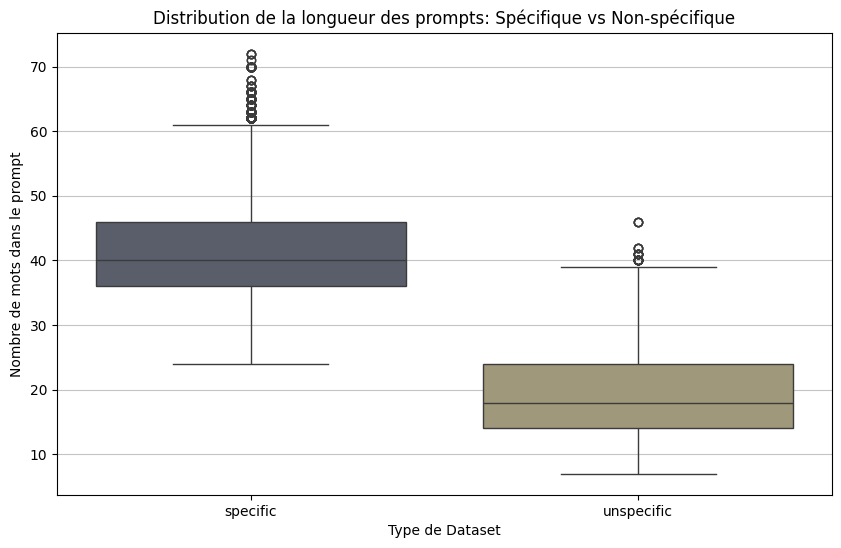

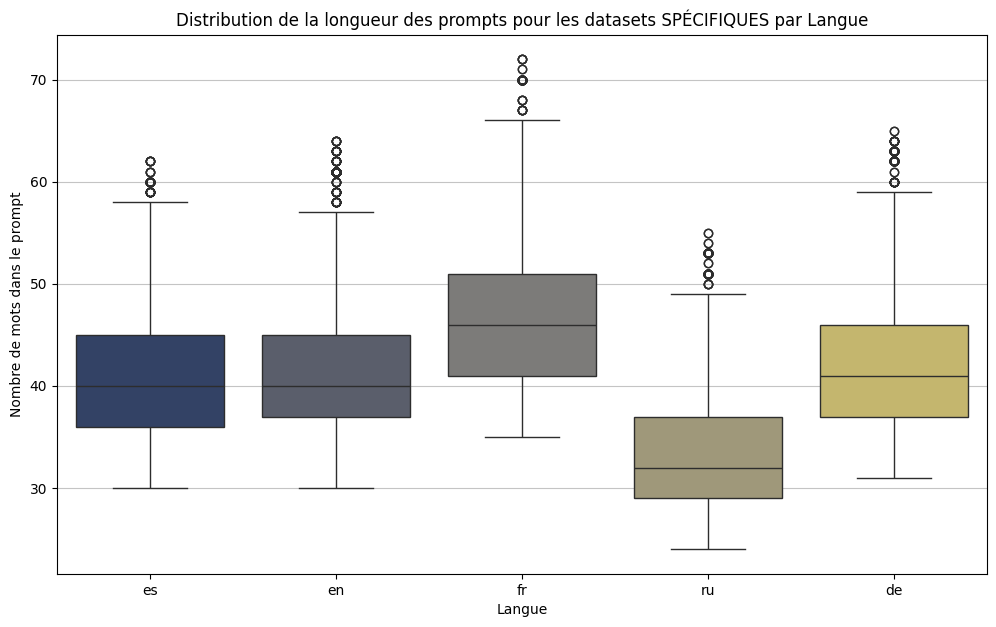

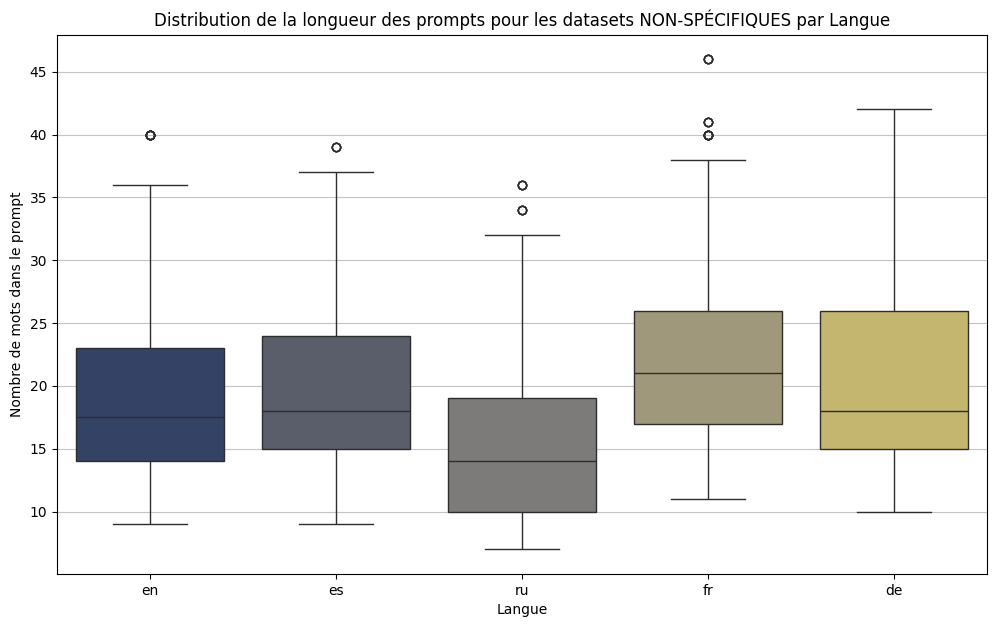

In [ ]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data_dir = "/content/data"

# --- CORRECTION 1 : Initialisation de la liste ---
all_dfs = []

print("Loading and preparing data for distribution analysis...")
for root, dirs, files in os.walk(data_dir):
    for filename in files:
        # Ensure we only process relevant jsonl files and exclude submission metadata
        if filename.endswith(".jsonl") and not filename.startswith(
            "submission_metadata"
        ):
            filepath = os.path.join(root, filename)
            # The filename typically contains 'language_specificity' (e.g., 'ru_unspecific.jsonl')
            dataset_name_from_file = filename.replace(".jsonl", '')

            try:
                df = pd.read_json(filepath, lines=True)
                df["dataset_name"] = dataset_name_from_file
                # Assuming 'prompt' column exists in these jsonl files for word count
                if "prompt" in df.columns:
                    df["prompt_word_count"] = df["prompt"].apply(
                        lambda x: len(str(x).split())
                    )
                else:
                    print(
                        f"Warning: 'prompt' column not found in {filename}. 'prompt_word_count' will not be calculated for this file."
                    )
                    df["prompt_word_count"] = (
                        0  # Assign a default or handle as needed
                    )

                all_dfs.append(df)
            except KeyError as e:
                print(
                    f"Error: Column '{e}' not found in {filename}. Skipping this file."
                )
            except Exception as e:
                print(f"Error processing {filename}: {e}. Skipping this file.")

if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Combined data into combined_df with {len(combined_df)} rows.")
else:
    print(
        "No valid data files found or processed to create combined_df. Creating an empty DataFrame."
    )
    combined_df = pd.DataFrame(
        columns=[
            "dataset_name",
            "prompt",
            "prompt_word_count",
            "language",
            "specificity",
        ]
    )

# --- CORRECTION 2 : Sécurisation du split (évite les IndexError) ---
def extract_language(name):
    return name.split("_")[0] if "_" in name else name


def extract_specificity(name):
    return name.split("_")[1] if "_" in name else "unknown"


# Application des fonctions sécurisées
combined_df["language"] = combined_df["dataset_name"].apply(extract_language)
combined_df["specificity"] = combined_df["dataset_name"].apply(
    extract_specificity
)

# --- Graphique 1 ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="specificity",
    y="prompt_word_count",
    hue="specificity",
    data=combined_df,
    palette="cividis",
    legend=False,
)
plt.title("Distribution de la longueur des prompts: Spécifique vs Non-spécifique")
plt.xlabel("Type de Dataset")
plt.ylabel("Nombre de mots dans le prompt")
plt.grid(axis="y", alpha=0.75)
plt.show()

# --- Graphique 2 ---
plt.figure(figsize=(12, 7))
# Sécurité : on vérifie si des données existent pour éviter un graphique vide qui plante
specific_df = combined_df[combined_df["specificity"] == "specific"]
if not specific_df.empty:
    sns.boxplot(
        x="language",
        y="prompt_word_count",
        hue="language",
        data=specific_df,
        palette="cividis",
        legend=False,
    )
    plt.title(
        "Distribution de la longueur des prompts pour les datasets SPÉCIFIQUES par Langue"
    )
    plt.xlabel("Langue")
    plt.ylabel("Nombre de mots dans le prompt")
    plt.grid(axis="y", alpha=0.75)
    plt.show()

# --- Graphique 3 ---
plt.figure(figsize=(12, 7))
unspecific_df = combined_df[combined_df["specificity"] == "unspecific"]
if not unspecific_df.empty:
    sns.boxplot(
        x="language",
        y="prompt_word_count",
        hue="language",
        data=unspecific_df,
        palette="cividis",
        legend=False,
    )
    plt.title(
        "Distribution de la longueur des prompts pour les datasets NON-SPÉCIFIQUES par Langue"
    )
    plt.xlabel("Langue")
    plt.ylabel("Nombre de mots dans le prompt")
    plt.grid(axis="y", alpha=0.75)
    plt.show()

# Analyse quantitative

## Robustesse des providers

In [ ]:
print("\nAnalyse de la robustesse des providers (longueur des réponses et réponses vides):\n")

# Load data from the data folder
data_dir = './data'
submission_data = {}

# Walk through the data directory and load all JSONL files
for root, dirs, files in os.walk(data_dir):
    for filename in files:
        if filename.endswith('.jsonl') and not filename.startswith('submission_metadata'):
            filepath = os.path.join(root, filename)
            dataset_name = filename.replace('.jsonl', '')

            try:
                df = pd.read_json(filepath, lines=True)
                submission_data[dataset_name] = df
            except Exception as e:
                print(f"Error loading {filename}: {e}")

robustness_stats = []

for dataset_name, df_sub in submission_data.items():
    response_col_name = None
    if 'answer' in df_sub.columns:
        response_col_name = 'answer'
    else:
        # Attempt to infer the response column
        # Assuming the response column is the one that's not 'id' or 'prompt'
        other_cols = [col for col in df_sub.columns if col not in ['id', 'prompt']]
        if len(other_cols) == 1:
            response_col_name = other_cols[0]
            print(f"Inférence: La colonne de réponse pour {dataset_name} est '{response_col_name}'.")
        elif len(other_cols) > 1:
            print(f"Avertissement: Plusieurs colonnes potentielles de réponse trouvées pour {dataset_name}: {other_cols}. Utilisation de la première '{other_cols[0]}'.")
            response_col_name = other_cols[0]
        else:
            print(f"Avertissement: Impossible d'inférer la colonne de réponse pour {dataset_name}. Colonnes disponibles: {df_sub.columns.tolist()}")

    if response_col_name:
        df_sub['response_word_count'] = df_sub[response_col_name].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
        df_sub['is_empty_response'] = df_sub[response_col_name].apply(lambda x: pd.isna(x) or str(x).strip() == '')

        total_responses = len(df_sub)
        empty_responses = df_sub['is_empty_response'].sum()
        empty_response_percentage = (empty_responses / total_responses * 100) if total_responses > 0 else 0

        robustness_stats.append({
            'Dataset': dataset_name,
            'Nombre total de réponses': total_responses,
            'Nombre de réponses vides': empty_responses,
            '% de réponses vides': f"{empty_response_percentage:.2f}%",
            'Longueur moyenne des réponses (mots)': f"{df_sub['response_word_count'].mean():.2f}",
            'Longueur médiane des réponses (mots)': f"{df_sub['response_word_count'].median():.0f}",
            'Longueur minimale des réponses (mots)': int(df_sub['response_word_count'].min()),
            'Longueur maximale des réponses (mots)': int(df_sub['response_word_count'].max())
        })
    else:
        print(f"Analyse ignorée pour {dataset_name} en raison de l'absence de colonne de réponse.")

if robustness_stats:
    robustness_df = pd.DataFrame(robustness_stats)
    display(robustness_df)
else:
    print("Aucune donnée de soumission valide trouvée pour l'analyse de robustesse après inférence.")


Analyse de la robustesse des providers (longueur des réponses et réponses vides):



,Dataset,Nombre total de réponses,Nombre de réponses vides,% de réponses vides,Longueur moyenne des réponses (mots),Longueur médiane des réponses (mots),Longueur minimale des réponses (mots),Longueur maximale des réponses (mots)
0,es_specific,4140,0,0.00%,34.42,34,13,133
1,en_specific,4140,0,0.00%,30.87,30,7,58
2,fr_specific,4104,0,0.00%,33.56,32,11,160
3,ru_specific,4140,0,0.00%,25.63,25,2,52
4,de_specific,4140,0,0.00%,36.09,36,2,115
5,en_unspecific,101,0,0.00%,34.17,34,22,47
6,es_unspecific,101,0,0.00%,36.24,35,21,136
7,ru_unspecific,101,0,0.00%,28.53,28,14,45
8,fr_unspecific,101,0,0.00%,35.95,35,17,59
9,de_unspecific,101,0,0.00%,40.04,38,23,72


## Récupération des réponses

In [ ]:
import os
import pandas as pd

print("Chargement de toutes les réponses du dataset...\n")

all_responses = {}
responses_data = []

# Walk through the data directory and extract answers
for root, dirs, files in os.walk("./data"):
    for filename in files:
        if filename.endswith(".jsonl") and not filename.startswith(
            "submission_metadata"
        ):
            filepath = os.path.join(root, filename)
            dataset_name = filename.replace(".jsonl", "")

            try:
                # Load JSONL file
                df = pd.read_json(filepath, lines=True)

                # --- CORRECTION ROBUSTE DES CHEMINS ---
                # rel_path donnera par exemple: "specific/baseline" ou "unspecific/cot_cultural"
                rel_path = os.path.relpath(root, "./data")
                path_parts = rel_path.split(os.sep)

                # On s'assure qu'on est bien dans la sous-structure attendue
                if len(path_parts) >= 2:
                    specificity = path_parts[0]  # 'specific' ou 'unspecific'
                    prompt_type = path_parts[1]  # 'baseline', 'cot_cultural', etc.
                else:
                    # Cas de secours si un fichier est mal placé directement dans ./data ou ./data/specific
                    specificity = (
                        path_parts[0] if len(path_parts) == 1 else "unknown"
                    )
                    prompt_type = "unknown"

                # Extract language from filename (e.g., 'en_specific' -> 'en')
                language = (
                    dataset_name.split("_")[0] if "_" in dataset_name else "unknown"
                )

                # Store answers for this dataset
                all_responses[dataset_name] = (
                    df[["id", "prompt", "answer"]].copy()
                    if "answer" in df.columns
                    else None
                )

                # If answers exist, add to consolidated list with metadata
                if "answer" in df.columns:
                    # Optimisation de la boucle pour de meilleures performances
                    for row in df[["id", "prompt", "answer"]].to_dict(
                        orient="records"
                    ):
                        responses_data.append(
                            {
                                "dataset_name": dataset_name,
                                "language": language,
                                "specificity": specificity,
                                "prompt_type": prompt_type,
                                "id": row["id"],
                                "prompt": row["prompt"],
                                "answer": row["answer"],
                            }
                        )

                    print(
                        f"✓ [{specificity}][{prompt_type}] {dataset_name}: {len(df)} réponses chargées"
                    )
                else:
                    print(f"✗ {dataset_name}: colonne 'answer' non trouvée")

            except Exception as e:
                print(f"✗ Erreur lors du chargement de {filename}: {e}")

# Create consolidated DataFrame with all responses
responses_df = pd.DataFrame(responses_data)

print(f"\n{'='*60}")
print(f"Total de datasets traités (clés uniques): {len(all_responses)}")
print(f"Total de lignes de réponses cumulées: {len(responses_df)}")

if not responses_df.empty:
    print(f"\nRépartition par spécificité:")
    print(responses_df["specificity"].value_counts())
    print(f"\nRépartition par type de prompt:")
    print(responses_df["prompt_type"].value_counts())
else:
    print("\nAttention: Aucune donnée n'a pu être consolidée.")

Chargement de toutes les réponses du dataset...

✓ [specific][rewritten_query] es_specific: 4140 réponses chargées
✓ [specific][rewritten_query] en_specific: 4140 réponses chargées
✓ [specific][rewritten_query] fr_specific: 4104 réponses chargées
✓ [specific][rewritten_query] ru_specific: 4140 réponses chargées
✓ [specific][rewritten_query] de_specific: 4140 réponses chargées
✓ [specific][baseline] es_specific: 4140 réponses chargées
✓ [specific][baseline] en_specific: 4140 réponses chargées
✓ [specific][baseline] fr_specific: 4104 réponses chargées
✓ [specific][baseline] ru_specific: 4140 réponses chargées
✓ [specific][baseline] de_specific: 4140 réponses chargées
✓ [unspecific][system_constrained] en_unspecific: 11 réponses chargées
✓ [unspecific][system_constrained] es_unspecific: 101 réponses chargées
✓ [unspecific][system_constrained] ru_unspecific: 101 réponses chargées
✓ [unspecific][system_constrained] fr_unspecific: 101 réponses chargées
✓ [unspecific][system_constrained] de_u

## Analyse sémantique embeddings

### Génération embeddings BERT

In [ ]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np

# Charger un modèle BERT multilingue pré-entraîné
# 'paraphrase-multilingual-MiniLM-L12-v2' est un bon choix pour l'efficacité et la performance multilingue.
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# Dictionnaire pour stocker les embeddings BERT pour chaque dataset de soumission
submission_embeddings_bert = {}

# Vérifier que responses_df existe (DataFrame construit à partir de responses_data)
if 'responses_df' in locals() or 'responses_df' in globals():
    # Générer les embeddings pour chaque dataset présent dans le DataFrame consolidé
    unique_datasets = responses_df['dataset_name'].unique()

    for dataset_name in unique_datasets:
        print(f"Génération des embeddings pour {dataset_name}...")
        df_sub = responses_df[responses_df['dataset_name'] == dataset_name]

        # Extraire les réponses, en s'assurant qu'elles sont des chaînes de caractères et non vides
        responses = df_sub['answer'].fillna('').astype(str).tolist()

        # Générer les embeddings pour toutes les réponses du dataset
        embeddings = model.encode(responses, show_progress_bar=True)
        submission_embeddings_bert[dataset_name] = embeddings
else:
    # Alternative directe depuis la liste brute responses_data si responses_df n'est pas encore défini
    # On regroupe les réponses par dataset_name
    from collections import defaultdict
    grouped_responses = defaultdict(list)
    for row in responses_data:
        grouped_responses[row['dataset_name']].append(str(row['answer'] or ''))

    for dataset_name, responses in grouped_responses.items():
        print(f"Génération des embeddings pour {dataset_name}...")
        embeddings = model.encode(responses, show_progress_bar=True)
        submission_embeddings_bert[dataset_name] = embeddings

print("\nEmbeddings BERT pour tous les datasets de soumission générés.")
# Vous pouvez maintenant accéder aux embeddings pour un dataset spécifique comme :
# bert_embeddings_ru_unspecific = submission_embeddings_bert['ru_unspecific']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Génération des embeddings pour fr_unspecific...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Génération des embeddings pour de_unspecific...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]


Embeddings BERT pour tous les datasets de soumission générés.


### Calcul de la Similarité Cosinus Inter-langues BERT (specific)

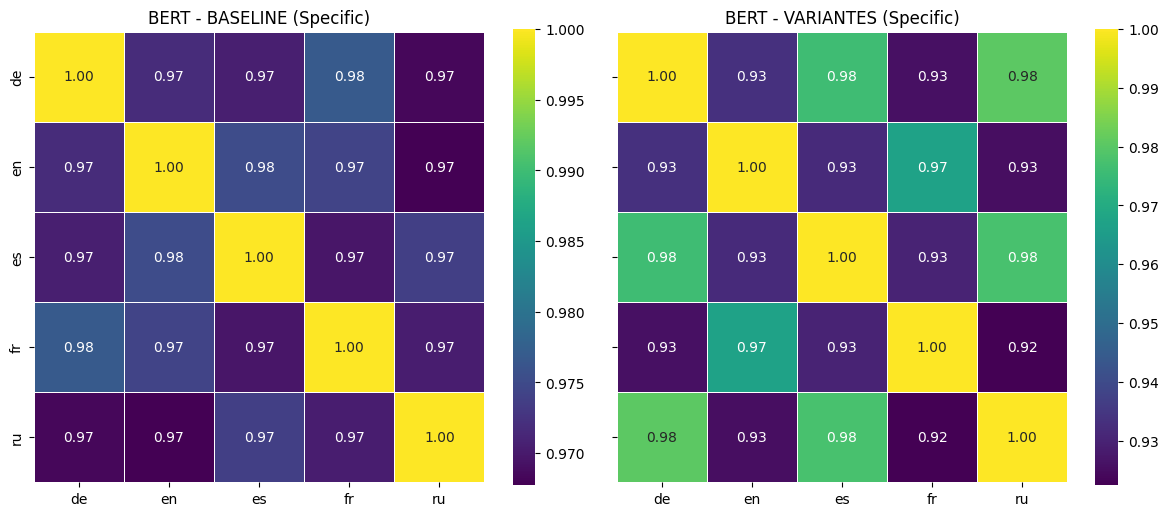



Analyse de similarité terminée, uniquement pour les données 'specific'.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_baseline_vs_variants_similarity_bert(embeddings_dict, responses_df, embedding_type='BERT'):
    # 1. Create a consolidated DataFrame with embeddings and metadata
    all_bert_data = []

    for dataset_name, embeddings_array in embeddings_dict.items():
        # Get the subset of responses_df corresponding to this dataset
        df_sub_responses = responses_df[responses_df['dataset_name'] == dataset_name].copy()

        # Ensure the number of embeddings matches the number of responses for this dataset
        if len(embeddings_array) != len(df_sub_responses):
            print(f"Mismatch: {len(embeddings_array)} embeddings for {dataset_name}, but {len(df_sub_responses)} rows in responses_df. Skipping.")
            continue

        # Add embeddings to the subset DataFrame
        df_sub_responses['embedding'] = list(embeddings_array)

        # Extend the list with the rows from this dataset
        all_bert_data.append(df_sub_responses)

    if not all_bert_data:
        print("Aucune donnée BERT valide trouvée pour l'analyse.")
        return

    # Concatenate all into a single DataFrame
    df_with_bert_embeddings = pd.concat(all_bert_data, ignore_index=True)

    # 2. Filter strictly for 'specific' data
    df_filtered = df_with_bert_embeddings[df_with_bert_embeddings['specificity'] == 'specific'].copy()

    if df_filtered.empty:
        print(f"Aucune donnée '{embedding_type}' 'specific' trouvée après filtrage.")
        return

    # 3. Binary separation: 'baseline' on one side, and ALL others become 'variantes'
    df_filtered['group_type'] = df_filtered['prompt_type'].apply(
        lambda x: 'baseline' if str(x).lower() == 'baseline' else 'variantes'
    )

    # We fix the order to have Baseline on the left and Variants on the right
    group_types = ['baseline', 'variantes']

    # 4. Initialize the grid (1 row, 2 columns of equal size)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    # 5. Calculate and display for each group
    for idx, group_name in enumerate(group_types):
        df_group = df_filtered[df_filtered['group_type'] == group_name]

        if df_group.empty:
            print(f"Aucune donnée pour le groupe '{group_name}' (specific, {embedding_type}).")
            continue

        # Calculate the mean embedding per language for this merged group
        lang_embeddings = {}
        for lang, group in df_group.groupby('language'):
            # Each 'embedding' column element is already a numpy array
            vectors = np.array(list(group['embedding']))
            lang_embeddings[lang] = np.mean(vectors, axis=0)

        languages = sorted(list(lang_embeddings.keys()))
        if not languages:
            continue

        similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

        for i in range(len(languages)):
            for j in range(i, len(languages)):
                lang1 = languages[i]
                lang2 = languages[j]

                emb1 = lang_embeddings.get(lang1)
                emb2 = lang_embeddings.get(lang2)

                if emb1 is not None and emb2 is not None:
                    similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                    similarity_matrix.loc[lang1, lang2] = similarity
                    similarity_matrix.loc[lang2, lang1] = similarity

        # Display the heatmap with a strict 1:1 ratio (square=True)
        sns.heatmap(
            similarity_matrix,
            annot=True,
            cmap='viridis',
            fmt=".2f",
            linewidths=.5,
            square=True,
            cbar_kws={"shrink": 0.8},
            ax=axes[idx]
        )
        axes[idx].set_title(f'{embedding_type} - {group_name.upper()} (Specific)')

    plt.tight_layout()
    plt.show()

    print("\n")
    print("Analyse de similarité terminée, uniquement pour les données 'specific'.")

# Call the new function with BERT embeddings and responses_df
plot_baseline_vs_variants_similarity_bert(submission_embeddings_bert, responses_df, 'BERT')


### Calcul de la Similarité Cosinus Inter-langues BERT (unspecific)

### Calcul de la Similarité Cosinus Inter-langues (BERT) - Jeu de données unspecific

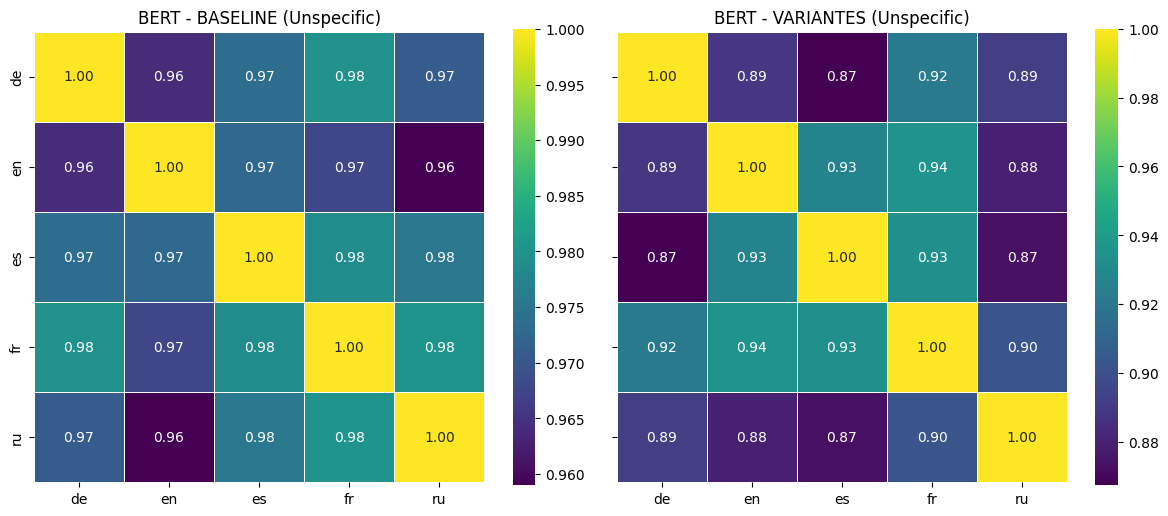



Analyse de similarité terminée, uniquement pour les données 'unspecific'.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_baseline_vs_variants_similarity_bert_unspecific(embeddings_dict, responses_df, embedding_type='BERT'):
    # 1. Create a consolidated DataFrame with embeddings and metadata
    all_bert_data = []

    for dataset_name, embeddings_array in embeddings_dict.items():
        # Get the subset of responses_df corresponding to this dataset
        df_sub_responses = responses_df[responses_df['dataset_name'] == dataset_name].copy()

        # Ensure the number of embeddings matches the number of responses for this dataset
        if len(embeddings_array) != len(df_sub_responses):
            print(f"Mismatch: {len(embeddings_array)} embeddings for {dataset_name}, but {len(df_sub_responses)} rows in responses_df. Skipping.")
            continue

        # Add embeddings to the subset DataFrame
        df_sub_responses['embedding'] = list(embeddings_array)

        # Extend the list with the rows from this dataset
        all_bert_data.append(df_sub_responses)

    if not all_bert_data:
        print("Aucune donnée BERT valide trouvée pour l'analyse.")
        return

    # Concatenate all into a single DataFrame
    df_with_bert_embeddings = pd.concat(all_bert_data, ignore_index=True)

    # 2. Filter strictly for 'unspecific' data
    df_filtered = df_with_bert_embeddings[df_with_bert_embeddings['specificity'] == 'unspecific'].copy()

    if df_filtered.empty:
        print(f"Aucune donnée '{embedding_type}' 'unspecific' trouvée après filtrage.")
        return

    # 3. Binary separation: 'baseline' on one side, and ALL others become 'variantes'
    df_filtered['group_type'] = df_filtered['prompt_type'].apply(
        lambda x: 'baseline' if str(x).lower() == 'baseline' else 'variantes'
    )

    # We fix the order to have Baseline on the left and Variants on the right
    group_types = ['baseline', 'variantes']

    # 4. Initialize the grid (1 row, 2 columns of equal size)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    # 5. Calculate and display for each group
    for idx, group_name in enumerate(group_types):
        df_group = df_filtered[df_filtered['group_type'] == group_name]

        if df_group.empty:
            print(f"Aucune donnée pour le groupe '{group_name}' (unspecific, {embedding_type}).")
            # Hide the empty subplot
            fig.delaxes(axes[idx])
            continue

        # Calculate the mean embedding per language for this merged group
        lang_embeddings = {}
        for lang, group in df_group.groupby('language'):
            # Each 'embedding' column element is already a numpy array
            vectors = np.array(list(group['embedding']))
            lang_embeddings[lang] = np.mean(vectors, axis=0)

        languages = sorted(list(lang_embeddings.keys()))
        if not languages:
            continue

        similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

        for i in range(len(languages)):
            for j in range(i, len(languages)):
                lang1 = languages[i]
                lang2 = languages[j]

                emb1 = lang_embeddings.get(lang1)
                emb2 = lang_embeddings.get(lang2)

                if emb1 is not None and emb2 is not None:
                    similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                    similarity_matrix.loc[lang1, lang2] = similarity
                    similarity_matrix.loc[lang2, lang1] = similarity

        # Display the heatmap with a strict 1:1 ratio (square=True)
        sns.heatmap(
            similarity_matrix,
            annot=True,
            cmap='viridis',
            fmt=".2f",
            linewidths=.5,
            square=True,
            cbar_kws={"shrink": 0.8},
            ax=axes[idx]
        )
        axes[idx].set_title(f'{embedding_type} - {group_name.upper()} (Unspecific)')

    plt.tight_layout()
    plt.show()

    print("\n")
    print("Analyse de similarité terminée, uniquement pour les données 'unspecific'.")

# Call the new function with BERT embeddings and responses_df
plot_baseline_vs_variants_similarity_bert_unspecific(submission_embeddings_bert, responses_df, 'BERT')

### Visualisation des Clusters t-SNE BERT

1. ANALYSE DE LA DIVERSITÉ CULTURELLE (UNSPECIFIC) - BERT


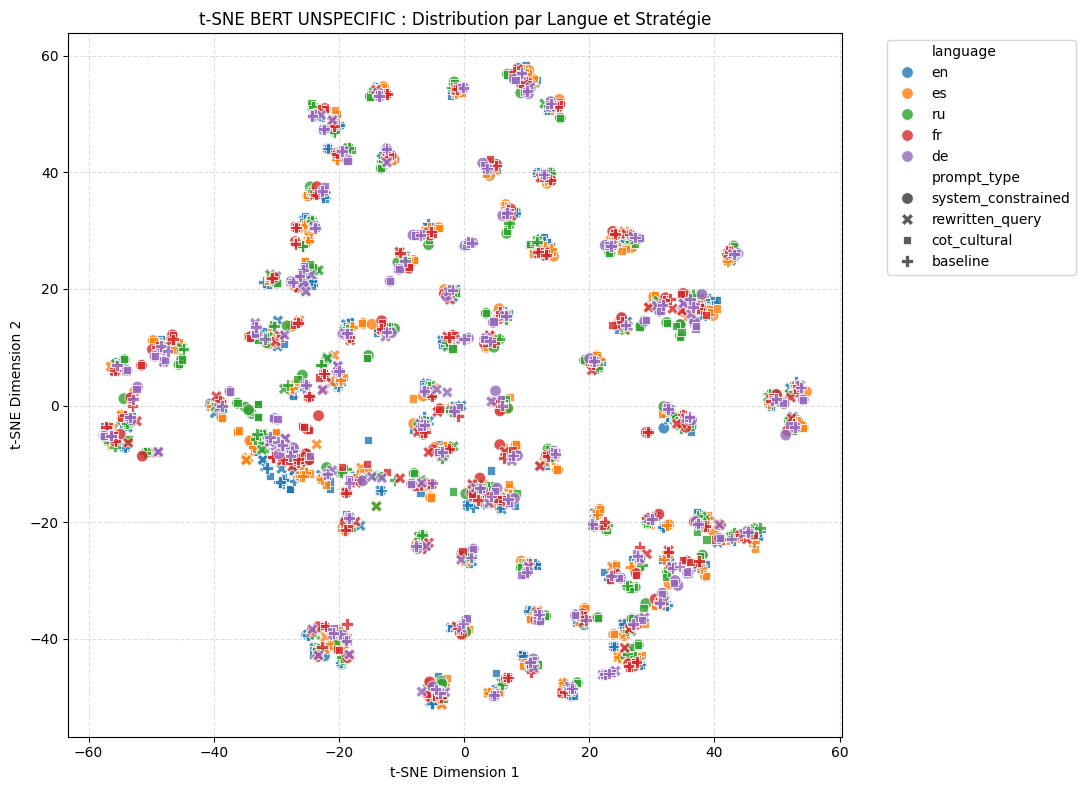

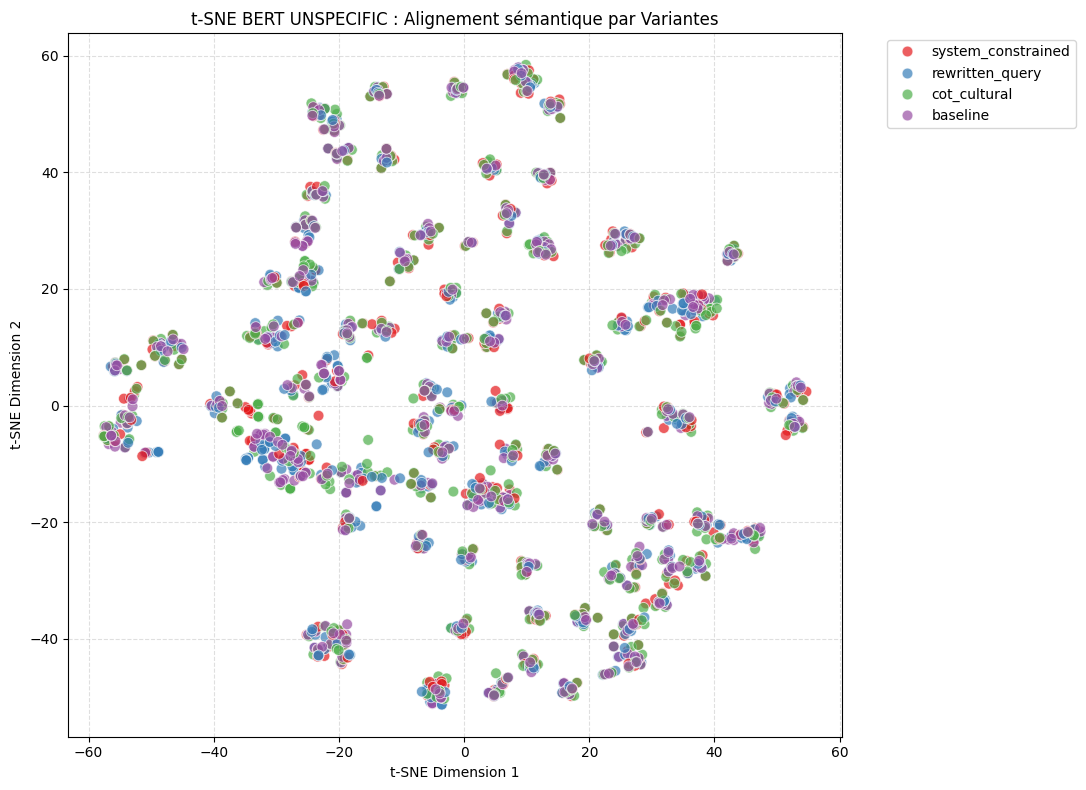


2. ANALYSE DE LA ROBUSTESSE CULTURELLE (SPECIFIC) - BERT


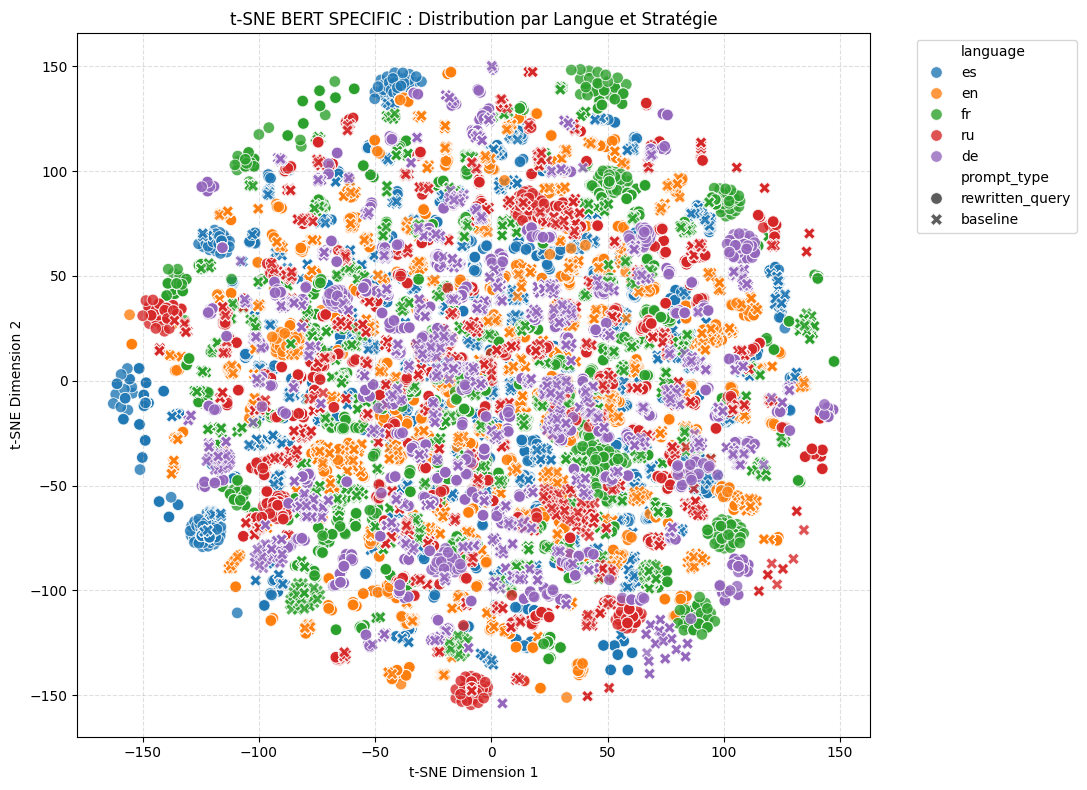

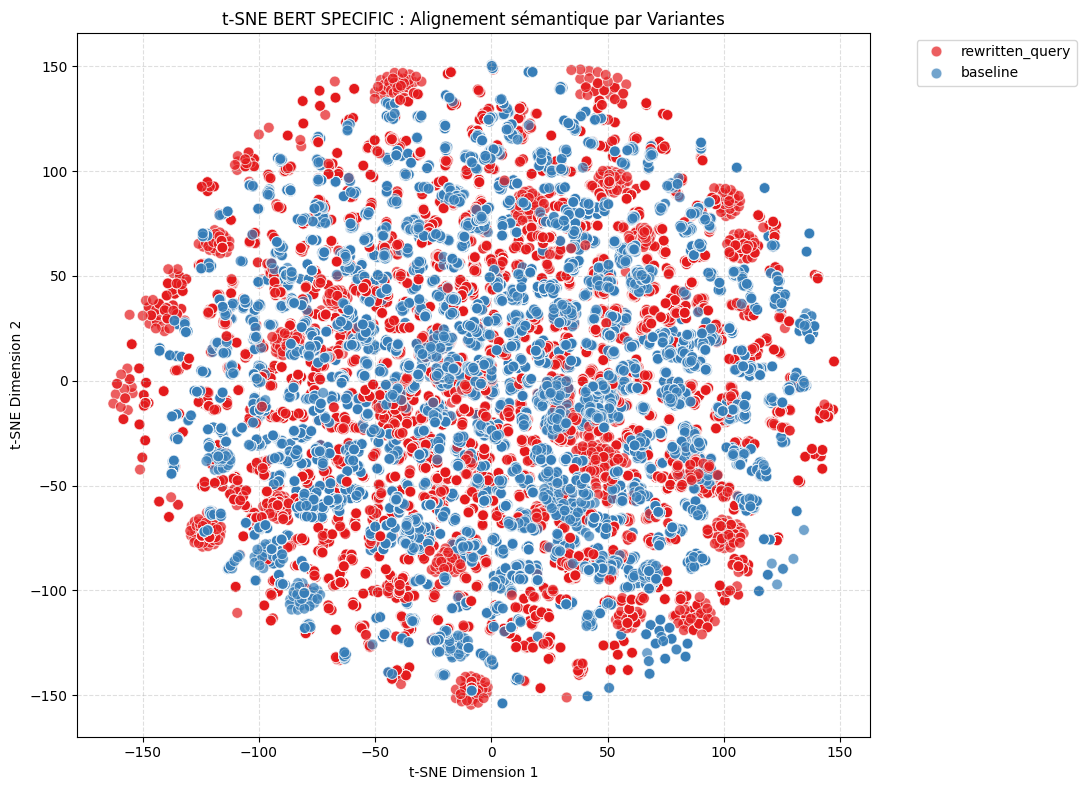

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# 1. Consolidate responses_df with BERT embeddings
# This step prepares a DataFrame similar to how responses_df was used for Word2Vec,
# but now includes the BERT embeddings.
bert_responses_data = []
for dataset_name in responses_df['dataset_name'].unique():
    df_sub_responses = responses_df[responses_df['dataset_name'] == dataset_name].copy()
    embeddings_array = submission_embeddings_bert.get(dataset_name)

    if embeddings_array is None:
        print(f"Warning: No BERT embeddings found for dataset {dataset_name}. Skipping.")
        continue

    if len(embeddings_array) != len(df_sub_responses):
        print(f"Mismatch: {len(embeddings_array)} embeddings for {dataset_name}, but {len(df_sub_responses)} rows in responses_df. Skipping.")
        continue

    df_sub_responses['bert_embedding'] = list(embeddings_array) # Store as list of arrays
    bert_responses_data.append(df_sub_responses)

if not bert_responses_data:
    print("No BERT responses data available for analysis.")
    # Create an empty DataFrame to avoid errors later
    bert_responses_df = pd.DataFrame(columns=responses_df.columns.tolist() + ['bert_embedding'])
else:
    bert_responses_df = pd.concat(bert_responses_data, ignore_index=True)

# Define the function for BERT t-SNE analysis, mirroring the Word2Vec structure
def run_project_bert_analysis(df_source_with_bert_embeddings, specificity_type):
    """Génère une analyse sémantique t-SNE pour BERT conforme aux exigences du challenge ELOQUENT."""
    # 1. Isolation stricte du type de dataset (specific ou unspecific)
    df_subset = df_source_with_bert_embeddings[df_source_with_bert_embeddings["specificity"] == specificity_type].copy()

    if df_subset.empty:
        print(
            f"Aucune donnée pour {specificity_type} ou DataFrame source vide."
        )
        return

    if "bert_embedding" not in df_subset.columns:
        print(
            "Erreur : La colonne 'bert_embedding' est introuvable dans le DataFrame."
        )
        return

    # 2. Extraction directe des vecteurs denses BERT
    # Conversion de la série de listes/arrays en une matrice NumPy unique
    embeddings = np.array(list(df_subset["bert_embedding"]))

    # Handle cases with insufficient samples for clustering or t-SNE
    if len(embeddings) < 2: # At least 2 samples for distance calculations in K-Means/t-SNE
        print(f"Nombre insuffisant d'échantillons ({len(embeddings)}) pour l'analyse BERT t-SNE pour {specificity_type}. Au moins 2 échantillons sont requis.")
        return

    # 3. Clustering K-Means basé sur le nombre de langues réelles
    n_languages = df_subset["language"].nunique()
    # Ensure n_clusters is at least 1 and less than n_samples
    num_clusters_for_subset = max(1, min(n_languages, len(embeddings) - 1)) # Ensure n_clusters is valid
    if num_clusters_for_subset == 0: # This can happen if len(embeddings) is 1 (already caught by len(embeddings) < 2)
        print(f"Impossible de réaliser le clustering K-Means pour {specificity_type}: nombre de clusters invalide ({num_clusters_for_subset}).")
        return

    kmeans = KMeans(n_clusters=num_clusters_for_subset, random_state=42, n_init=10)
    df_subset["cluster_kmeans"] = kmeans.fit_predict(embeddings)

    # 4. Réduction de dimensionnalité t-SNE
    # Perplexity should be less than the number of samples
    perpl = min(30, max(5, len(embeddings) // 2))
    if perpl >= len(embeddings): # Perplexity must be less than the number of samples
        perpl = max(1, len(embeddings) - 1) # Set to a valid value

    tsne = TSNE(
        n_components=2, random_state=42, perplexity=perpl, max_iter=1000
    )
    tsne_results = tsne.fit_transform(embeddings)

    df_subset["tsne-1"] = tsne_results[:, 0]
    df_subset["tsne-2"] = tsne_results[:, 1]

    # 5. Visualisations pour le rapport (Lot D)
    # Graphique A : Focus sur l'impact culturel (Langues)
    plt.figure(figsize=(11, 8))
    sns.scatterplot(
        x="tsne-1",
        y="tsne-2",
        hue="language",
        style="prompt_type",
        data=df_subset,
        palette="tab10",
        alpha=0.8,
        s=70,
    )
    plt.title(
        f"t-SNE BERT {specificity_type.upper()} : Distribution par Langue et Stratégie"
    )
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # Graphique B : Focus sur l'impact des Variantes (Lot C)
    plt.figure(figsize=(11, 8))
    sns.scatterplot(
        x="tsne-1",
        y="tsne-2",
        hue="prompt_type",
        data=df_subset,
        palette="Set1",
        alpha=0.7,
        s=60,
    )
    plt.title(
        f"t-SNE BERT {specificity_type.upper()} : Alignement sémantique par Variantes"
    )
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# --- Exécution pour les deux scénarios BERT ---
if not bert_responses_df.empty:
    print("=" * 60)
    print("1. ANALYSE DE LA DIVERSITÉ CULTURELLE (UNSPECIFIC) - BERT")
    print("=" * 60)
    run_project_bert_analysis(bert_responses_df, "unspecific")

    print("\n" + "=" * 60)
    print("2. ANALYSE DE LA ROBUSTESSE CULTURELLE (SPECIFIC) - BERT")
    print("=" * 60)
    run_project_bert_analysis(bert_responses_df, "specific")
else:
    print("Impossible de lancer l'analyse BERT t-SNE car 'bert_responses_df' est vide ou n'a pu être créé.")


### Dispersion des Clusters dans l'espace t-SNE (BERT)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

print("Calcul de la dispersion des clusters BERT")
print("=" * 60)

# === DONNÉES SPECIFIC ===
print("\nDonnées SPECIFIC")
print("-" * 40)

# Filter specific data from bert_responses_df
df_specific_bert = bert_responses_df[bert_responses_df["specificity"] == "specific"].copy()

if not df_specific_bert.empty and "bert_embedding" in df_specific_bert.columns:
    embeddings_specific = np.array(list(df_specific_bert["bert_embedding"]))

    if len(embeddings_specific) < 2:
        print("Nombre insuffisant d'échantillons pour l'analyse spécifique (BERT).")
    else:
        # Clustering K-Means based on the number of languages
        n_languages_specific = df_specific_bert["language"].nunique()
        # Ensure n_clusters is at least 1 and less than n_samples
        num_clusters_specific = max(1, min(n_languages_specific, len(embeddings_specific) - 1))

        if num_clusters_specific > 0:
            kmeans_specific = KMeans(n_clusters=num_clusters_specific, random_state=42, n_init=10)
            df_specific_bert["cluster"] = kmeans_specific.fit_predict(embeddings_specific)
        else:
            # Assign all to one cluster if clustering is not possible (e.g., only one sample or cluster)
            df_specific_bert["cluster"] = 0

        # t-SNE reduction
        perpl_specific = min(30, max(5, len(embeddings_specific) // 2))
        if perpl_specific >= len(embeddings_specific):
            perpl_specific = max(1, len(embeddings_specific) - 1)
        if perpl_specific < 1: # t-SNE needs perplexity >= 1
             perpl_specific = 1

        tsne_specific = TSNE(n_components=2, random_state=42, perplexity=perpl_specific, max_iter=1000)
        tsne_results_specific = tsne_specific.fit_transform(embeddings_specific)

        df_specific_bert["tsne-2d-one"] = tsne_results_specific[:, 0]
        df_specific_bert["tsne-2d-two"] = tsne_results_specific[:, 1]

        # Calcul de la dispersion : écart-type et distance moyenne au centre
        dispersion_specific = []
        for cluster_id in df_specific_bert["cluster"].unique():
            cluster_data = df_specific_bert[df_specific_bert["cluster"] == cluster_id]

            if len(cluster_data) > 0:
                # Écart-type dans l'espace t-SNE
                std_1 = cluster_data["tsne-2d-one"].std()
                std_2 = cluster_data["tsne-2d-two"].std()

                # Distance moyenne au centre du cluster
                center_1 = cluster_data["tsne-2d-one"].mean()
                center_2 = cluster_data["tsne-2d-two"].mean()
                distances = np.sqrt((cluster_data["tsne-2d-one"] - center_1)**2 +
                                   (cluster_data["tsne-2d-two"] - center_2)**2)
                mean_distance = distances.mean()

                dispersion_specific.append({
                    "Cluster": cluster_id,
                    "Std Dim 1": round(std_1, 3),
                    "Std Dim 2": round(std_2, 3),
                    "Avg Distance to Center": round(mean_distance, 3),
                    "Nb Points": len(cluster_data)
                })

        df_dispersion_specific_bert = pd.DataFrame(dispersion_specific)
        print("\nDispersion par cluster (Specific):")
        display(df_dispersion_specific_bert)
else:
    print("Pas de données specific ou colonne 'bert_embedding' manquante pour BERT.")

# === DONNÉES UNSPECIFIC ===
print("\n\nDonnées UNSPECIFIC")
print("-" * 40)

# Filter unspecific data from bert_responses_df
df_unspecific_bert = bert_responses_df[bert_responses_df["specificity"] == "unspecific"].copy()

if not df_unspecific_bert.empty and "bert_embedding" in df_unspecific_bert.columns:
    embeddings_unspecific = np.array(list(df_unspecific_bert["bert_embedding"]))

    if len(embeddings_unspecific) < 2:
        print("Nombre insuffisant d'échantillons pour l'analyse non-spécifique (BERT).")
    else:
        # Clustering K-Means based on the number of languages
        n_languages_unspecific = df_unspecific_bert["language"].nunique()
        # Ensure n_clusters is at least 1 and less than n_samples
        num_clusters_unspecific = max(1, min(n_languages_unspecific, len(embeddings_unspecific) - 1))

        if num_clusters_unspecific > 0:
            kmeans_unspecific = KMeans(n_clusters=num_clusters_unspecific, random_state=42, n_init=10)
            df_unspecific_bert["cluster"] = kmeans_unspecific.fit_predict(embeddings_unspecific)
        else:
            # Assign all to one cluster if clustering is not possible
            df_unspecific_bert["cluster"] = 0

        # t-SNE reduction
        perpl_unspecific = min(30, max(5, len(embeddings_unspecific) // 2))
        if perpl_unspecific >= len(embeddings_unspecific):
            perpl_unspecific = max(1, len(embeddings_unspecific) - 1)
        if perpl_unspecific < 1:
            perpl_unspecific = 1

        tsne_unspecific = TSNE(n_components=2, random_state=42, perplexity=perpl_unspecific, max_iter=1000)
        tsne_results_unspecific = tsne_unspecific.fit_transform(embeddings_unspecific)

        df_unspecific_bert["tsne-2d-one"] = tsne_results_unspecific[:, 0]
        df_unspecific_bert["tsne-2d-two"] = tsne_results_unspecific[:, 1]

        # Calcul de la dispersion : écart-type et distance moyenne au centre
        dispersion_unspecific = []
        for cluster_id in df_unspecific_bert["cluster"].unique():
            cluster_data = df_unspecific_bert[df_unspecific_bert["cluster"] == cluster_id]

            if len(cluster_data) > 0:
                # Écart-type dans l'espace t-SNE
                std_1 = cluster_data["tsne-2d-one"].std()
                std_2 = cluster_data["tsne-2d-two"].std()

                # Distance moyenne au centre du cluster
                center_1 = cluster_data["tsne-2d-one"].mean()
                center_2 = cluster_data["tsne-2d-two"].mean()
                distances = np.sqrt((cluster_data["tsne-2d-one"] - center_1)**2 +
                                   (cluster_data["tsne-2d-two"] - center_2)**2)
                mean_distance = distances.mean()

                dispersion_unspecific.append({
                    "Cluster": cluster_id,
                    "Std Dim 1": round(std_1, 3),
                    "Std Dim 2": round(std_2, 3),
                    "Avg Distance to Center": round(mean_distance, 3),
                    "Nb Points": len(cluster_data)
                })

        df_dispersion_unspecific_bert = pd.DataFrame(dispersion_unspecific)
        print("\nDispersion par cluster (Unspecific):")
        display(df_dispersion_unspecific_bert)
else:
    print("Pas de données unspecific ou colonne 'bert_embedding' manquante pour BERT.")

print("\n" + "=" * 60)

Calcul de la dispersion des clusters BERT

Données SPECIFIC
----------------------------------------

Dispersion par cluster (Specific):


,Cluster,Std Dim 1,Std Dim 2,Avg Distance to Center,Nb Points
0,4,29.513,35.893,42.470001,7534
1,2,60.648,62.427,76.278000,10697
2,3,43.258,49.486,58.681000,12812
3,0,34.930,33.150,42.122002,6059
4,1,36.785,52.465,53.869999,4226




Données UNSPECIFIC
----------------------------------------

Dispersion par cluster (Unspecific):


,Cluster,Std Dim 1,Std Dim 2,Avg Distance to Center,Nb Points
0,4,11.002,10.012,13.199000,344
1,1,19.506,13.972,21.188000,589
2,2,16.272,23.043,24.429001,407
3,3,27.722,22.875,31.875999,394
4,0,9.749,11.469,12.025000,196


### Score silhouette pour les clusters BERT

In [ ]:
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

print("=" * 60)
print("SILHOUETTE SCORE - BERT CLUSTERS")
print("=" * 60)

# === DONNÉES SPECIFIC ===
print("\nDonnées SPECIFIC")
print("-" * 40)

results_specific = []

if not df_specific_bert.empty and 'cluster' in df_specific_bert.columns and 'bert_embedding' in df_specific_bert.columns:
    # Extract embeddings and labels for all specific BERT data
    embeddings_specific_full = np.array(list(df_specific_bert['bert_embedding']))
    labels_specific = df_specific_bert['cluster'].values

    # Calculate global silhouette score for specific
    # Ensure enough samples and unique labels for silhouette score calculation
    if len(embeddings_specific_full) > 1 and len(np.unique(labels_specific)) > 1 and len(embeddings_specific_full) > len(np.unique(labels_specific)):
        score_global = silhouette_score(embeddings_specific_full, labels_specific)
        results_specific.append({
            'Prompt Type': 'ALL',
            'Silhouette Score': round(score_global, 3),
            'Nb Samples': len(embeddings_specific_full)
        })
    else:
        results_specific.append({
            'Prompt Type': 'ALL',
            'Silhouette Score': np.nan,
            'Nb Samples': len(embeddings_specific_full)
        })

    # Calculate by prompt type
    if 'prompt_type' in df_specific_bert.columns:
        unique_prompts = df_specific_bert['prompt_type'].unique()

        for prompt in unique_prompts:
            # Filter data for the current prompt type
            filtered_df_specific = df_specific_bert[df_specific_bert['prompt_type'] == prompt]

            embeddings_filtered = np.array(list(filtered_df_specific['bert_embedding']))
            labels_filtered = filtered_df_specific['cluster'].values

            # Check conditions for silhouette score calculation
            if len(embeddings_filtered) > 1 and len(np.unique(labels_filtered)) > 1 and len(embeddings_filtered) > len(np.unique(labels_filtered)):
                try:
                    score = silhouette_score(embeddings_filtered, labels_filtered)
                    results_specific.append({
                        'Prompt Type': prompt,
                        'Silhouette Score': round(score, 3),
                        'Nb Samples': len(embeddings_filtered)
                    })
                except Exception:
                    results_specific.append({
                        'Prompt Type': prompt,
                        'Silhouette Score': np.nan,
                        'Nb Samples': len(embeddings_filtered)
                    })
            else:
                results_specific.append({
                    'Prompt Type': prompt,
                    'Silhouette Score': np.nan,
                    'Nb Samples': len(embeddings_filtered)
                })

    df_results_specific = pd.DataFrame(results_specific)
    display(df_results_specific)
else:
    print("Pas de données specific ou colonnes manquantes ('cluster', 'bert_embedding') pour BERT.")

# === DONNÉES UNSPECIFIC ===
print("\n\nDonnées UNSPECIFIC")
print("-" * 40)

results_unspecific = []

if not df_unspecific_bert.empty and 'cluster' in df_unspecific_bert.columns and 'bert_embedding' in df_unspecific_bert.columns:
    # Extract embeddings and labels for all unspecific BERT data
    embeddings_unspecific_full = np.array(list(df_unspecific_bert['bert_embedding']))
    labels_unspecific = df_unspecific_bert['cluster'].values

    # Calculate global silhouette score for unspecific
    if len(embeddings_unspecific_full) > 1 and len(np.unique(labels_unspecific)) > 1 and len(embeddings_unspecific_full) > len(np.unique(labels_unspecific)):
        score_global = silhouette_score(embeddings_unspecific_full, labels_unspecific)
        results_unspecific.append({
            'Prompt Type': 'ALL',
            'Silhouette Score': round(score_global, 3),
            'Nb Samples': len(embeddings_unspecific_full)
        })
    else:
        results_unspecific.append({
            'Prompt Type': 'ALL',
            'Silhouette Score': np.nan,
            'Nb Samples': len(embeddings_unspecific_full)
        })

    # Calculate by prompt type
    if 'prompt_type' in df_unspecific_bert.columns:
        unique_prompts_unspecific = df_unspecific_bert['prompt_type'].unique()

        for prompt in unique_prompts_unspecific:
            # Filter data for the current prompt type
            filtered_df_unspecific = df_unspecific_bert[df_unspecific_bert['prompt_type'] == prompt]

            embeddings_filtered = np.array(list(filtered_df_unspecific['bert_embedding']))
            labels_filtered = filtered_df_unspecific['cluster'].values

            # Check conditions for silhouette score calculation
            if len(embeddings_filtered) > 1 and len(np.unique(labels_filtered)) > 1 and len(embeddings_filtered) > len(np.unique(labels_filtered)):
                try:
                    score = silhouette_score(embeddings_filtered, labels_filtered)
                    results_unspecific.append({
                        'Prompt Type': prompt,
                        'Silhouette Score': round(score, 3),
                        'Nb Samples': len(embeddings_filtered)
                    })
                except Exception:
                    results_unspecific.append({
                        'Prompt Type': prompt,
                        'Silhouette Score': np.nan,
                        'Nb Samples': len(embeddings_filtered)
                    })
            else:
                results_unspecific.append({
                    'Prompt Type': prompt,
                    'Silhouette Score': np.nan,
                    'Nb Samples': len(embeddings_filtered)
                })

    df_results_unspecific = pd.DataFrame(results_unspecific)
    display(df_results_unspecific)
else:
    print("Pas de données unspecific ou colonnes manquantes ('cluster', 'bert_embedding') pour BERT.")

print("\n" + "=" * 60)


SILHOUETTE SCORE - BERT CLUSTERS

Données SPECIFIC
----------------------------------------


,Prompt Type,Silhouette Score,Nb Samples
0,ALL,0.092,41328
1,rewritten_query,0.095,20664
2,baseline,0.095,20664




Données UNSPECIFIC
----------------------------------------


,Prompt Type,Silhouette Score,Nb Samples
0,ALL,0.076,1930
1,system_constrained,0.070,415
2,rewritten_query,0.079,505
3,cot_cultural,0.070,505
4,baseline,0.082,505


### Normalisation du jeu de données

In [ ]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Téléchargement automatique des ressources NLTK nécessaires
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Dictionnaire des stop words par langue
stopwords_dict = {
    'en': set(stopwords.words('english')),
    'es': set(stopwords.words('spanish')),
    'fr': set(stopwords.words('french')),
    'de': set(stopwords.words('german')),
    'ru': set(stopwords.words('russian'))
}

lemmatizer = WordNetLemmatizer()

def normalize_text(text, language='en', remove_stopwords=True, lemmatize=True):
    try:
        # Passage en minuscules
        text = str(text).lower()

        # Suppression de la ponctuation
        text = text.translate(str.maketrans('', '', string.punctuation))

        # Tokenisation
        tokens = word_tokenize(text)

        # Suppression des stop words
        if remove_stopwords and language in stopwords_dict:
            tokens = [token for token in tokens if token not in stopwords_dict[language]]

        # Suppression des tokens vides ou de taille 1
        tokens = [token for token in tokens if len(token) > 1]

        # Lemmatisation (NLTK ne gère nativement que l'anglais avec WordNet)
        if lemmatize and language == 'en':
            tokens = [lemmatizer.lemmatize(token) for token in tokens]

        return ' '.join(tokens)
    except Exception:
        return ""

# Application de la normalisation sur le DataFrame
responses_df['normalized_answer'] = responses_df.apply(
    lambda row: normalize_text(row['answer'], language=row['language']),
    axis=1
)

# Calcul des statistiques (sans affichage terminal)
responses_df['original_word_count'] = responses_df['answer'].apply(lambda x: len(str(x).split()))
responses_df['normalized_word_count'] = responses_df['normalized_answer'].apply(lambda x: len(str(x).split()) if str(x).strip() else 0)

lang_stats = responses_df.groupby('language').agg({
    'original_word_count': 'mean',
    'normalized_word_count': 'mean'
}).round(2)
lang_stats.columns = ['Mots originaux', 'Mots normalisés']

prompt_stats = responses_df.groupby('prompt_type').agg({
    'original_word_count': 'mean',
    'normalized_word_count': 'mean'
}).round(2)
prompt_stats.columns = ['Mots originaux', 'Mots normalisés']

sample_df = responses_df[['answer', 'normalized_answer']].head(3)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


### Génération embeddings Word2Vec

In [ ]:
from gensim.models import Word2Vec
import numpy as np

# 1. Préparation du corpus (liste de listes de mots) à partir de responses_df
valid_sentences = responses_df['normalized_answer'].fillna('').astype(str)
corpus = [sentence.split() for sentence in valid_sentences]

# 2. Entraînement du modèle Word2Vec sur l'ensemble des données
model = Word2Vec(
    sentences=corpus,
    vector_size=100,  # Dimension de l'embedding
    window=5,         # Fenêtre de contexte
    min_count=1,      # Fréquence minimale du mot (1 pour ne rien perdre)
    workers=4         # Optimisation CPU
)
word_vectors = model.wv

# 3. Fonction pour calculer l'embedding moyen d'une réponse
def get_document_embedding(text, wv_model, vector_size=100):
    words = str(text).split()
    valid_words = [word for word in words if word in wv_model]

    if not valid_words:
        return np.zeros(vector_size)

    return np.mean([wv_model[word] for word in valid_words], axis=0)

# 4. Ajout des embeddings individuels dans responses_df
responses_df['answer_embedding'] = responses_df['normalized_answer'].apply(
    lambda x: get_document_embedding(x, word_vectors, vector_size=100)
)

# 5. Création de la variable dictionnaire attendue par le script de similarité
submission_embeddings_word2vec = {}
for dataset_name, group in responses_df.groupby('dataset_name'):
    embeddings_list = list(group['answer_embedding'])
    submission_embeddings_word2vec[dataset_name] = np.array(embeddings_list)

# Mise à jour de ton échantillon par sécurité
sample_df = responses_df[['answer', 'normalized_answer', 'answer_embedding']].head(3)

### Calcul de la Similarité Cosinus Inter-langues Word2Vec (specific)

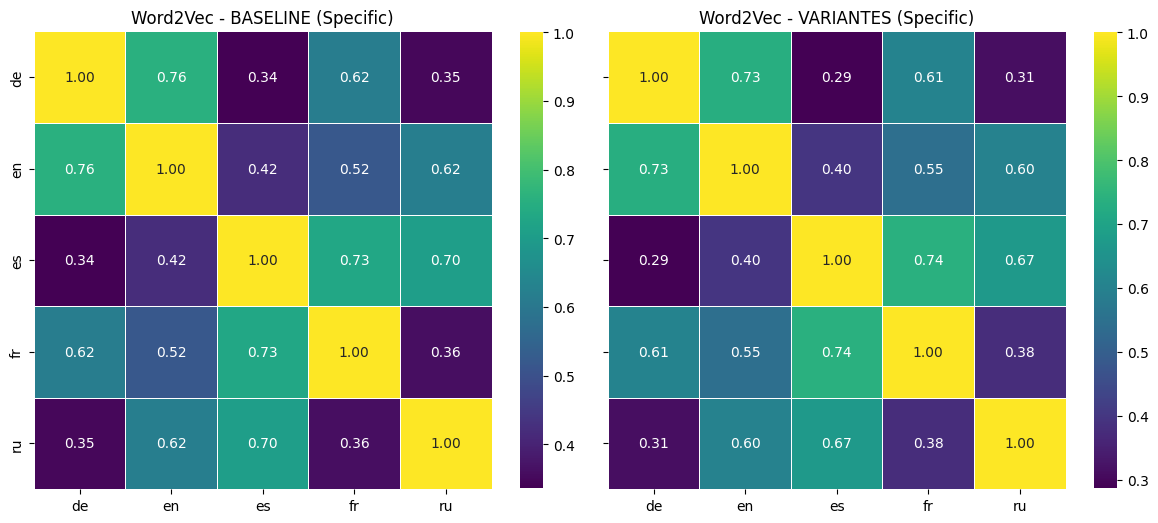

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_baseline_vs_variants_similarity(df, embedding_type='Word2Vec'):
    # 1. Filtrage strict sur les données 'specific'
    df_filtered = df[df['specificity'] == 'specific'].copy()

    if df_filtered.empty:
        return

    # 2. Séparation binaire : 'baseline' d'un côté, et TOUT le reste devient 'variantes'
    df_filtered['group_type'] = df_filtered['prompt_type'].apply(
        lambda x: 'baseline' if str(x).lower() in ['baseline', 'unknown'] else 'variantes'
    )

    # On fixe l'ordre pour avoir la Baseline à gauche et les Variantes à droite
    group_types = ['baseline', 'variantes']

    # 3. Initialisation de la grille (1 ligne, 2 colonnes de taille égale)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    # 4. Calcul et affichage pour chaque groupe
    for idx, group_name in enumerate(group_types):
        df_group = df_filtered[df_filtered['group_type'] == group_name]

        # Calcul de l'embedding moyen par langue pour ce groupe fusionné
        lang_embeddings = {}
        for lang, group in df_group.groupby('language'):
            vectors = np.array(list(group['answer_embedding']))
            lang_embeddings[lang] = np.mean(vectors, axis=0)

        languages = sorted(list(lang_embeddings.keys()))
        if not languages:
            continue

        similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

        for i in range(len(languages)):
            for j in range(i, len(languages)):
                lang1 = languages[i]
                lang2 = languages[j]

                emb1 = lang_embeddings.get(lang1)
                emb2 = lang_embeddings.get(lang2)

                if emb1 is not None and emb2 is not None:
                    similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                    similarity_matrix.loc[lang1, lang2] = similarity
                    similarity_matrix.loc[lang2, lang1] = similarity

        # Affichage de la heatmap avec un ratio 1:1 strict (square=True)
        sns.heatmap(
            similarity_matrix,
            annot=True,
            cmap='viridis',
            fmt=".2f",
            linewidths=.5,
            square=True,
            cbar_kws={"shrink": .8},
            ax=axes[idx]
        )
        axes[idx].set_title(f'{embedding_type} - {group_name.upper()} (Specific)')

    plt.tight_layout()
    plt.show()

# Lancement de la comparaison
plot_baseline_vs_variants_similarity(responses_df, 'Word2Vec')

### Calcul de la Similarité Cosinus Inter-langues Word2Vec (unspecific)

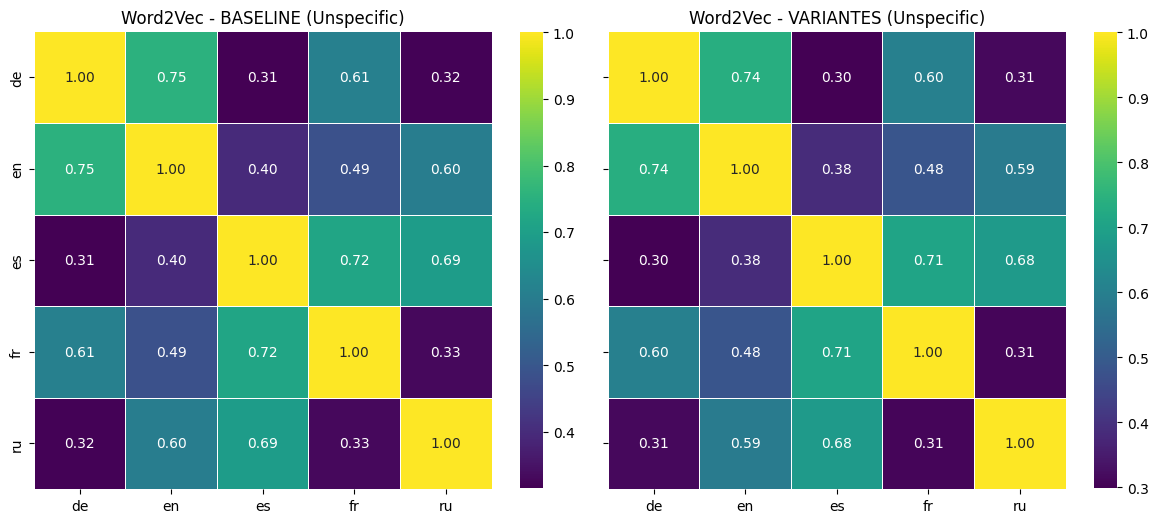

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_baseline_vs_variants_similarity_unspecific(df, embedding_type='Word2Vec'):
    # 1. Filtrage strict sur les données 'unspecific'
    df_filtered = df[df['specificity'] == 'unspecific'].copy()

    if df_filtered.empty:
        return

    # 2. Séparation binaire : 'baseline' d'un côté, et TOUT le reste devient 'variantes'
    df_filtered['group_type'] = df_filtered['prompt_type'].apply(
        lambda x: 'baseline' if str(x).lower() in ['baseline', 'unknown'] else 'variantes'
    )

    # Ordre d'affichage : Baseline à gauche, Variantes à droite
    group_types = ['baseline', 'variantes']

    # 3. Initialisation de la grille (1 ligne, 2 colonnes de taille égale)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    # 4. Calcul et affichage pour chaque groupe
    for idx, group_name in enumerate(group_types):
        df_group = df_filtered[df_filtered['group_type'] == group_name]

        # Calcul de l'embedding moyen par langue pour ce groupe fusionné
        lang_embeddings = {}
        for lang, group in df_group.groupby('language'):
            vectors = np.array(list(group['answer_embedding']))
            lang_embeddings[lang] = np.mean(vectors, axis=0)

        languages = sorted(list(lang_embeddings.keys()))
        if not languages:
            continue

        similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

        for i in range(len(languages)):
            for j in range(i, len(languages)):
                lang1 = languages[i]
                lang2 = languages[j]

                emb1 = lang_embeddings.get(lang1)
                emb2 = lang_embeddings.get(lang2)

                if emb1 is not None and emb2 is not None:
                    similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                    similarity_matrix.loc[lang1, lang2] = similarity
                    similarity_matrix.loc[lang2, lang1] = similarity

        # Affichage de la heatmap avec un ratio 1:1 strict (square=True)
        sns.heatmap(
            similarity_matrix,
            annot=True,
            cmap='viridis',
            fmt=".2f",
            linewidths=.5,
            square=True,
            cbar_kws={"shrink": .8},
            ax=axes[idx]
        )
        axes[idx].set_title(f'{embedding_type} - {group_name.upper()} (Unspecific)')

    plt.tight_layout()
    plt.show()

# Lancement de la comparaison pour unspecific
plot_baseline_vs_variants_similarity_unspecific(responses_df, 'Word2Vec')

### Visualisation des Clusters t-SNE Word2Vec

1. ANALYSE DE LA DIVERSITÉ CULTURELLE (UNSPECIFIC)


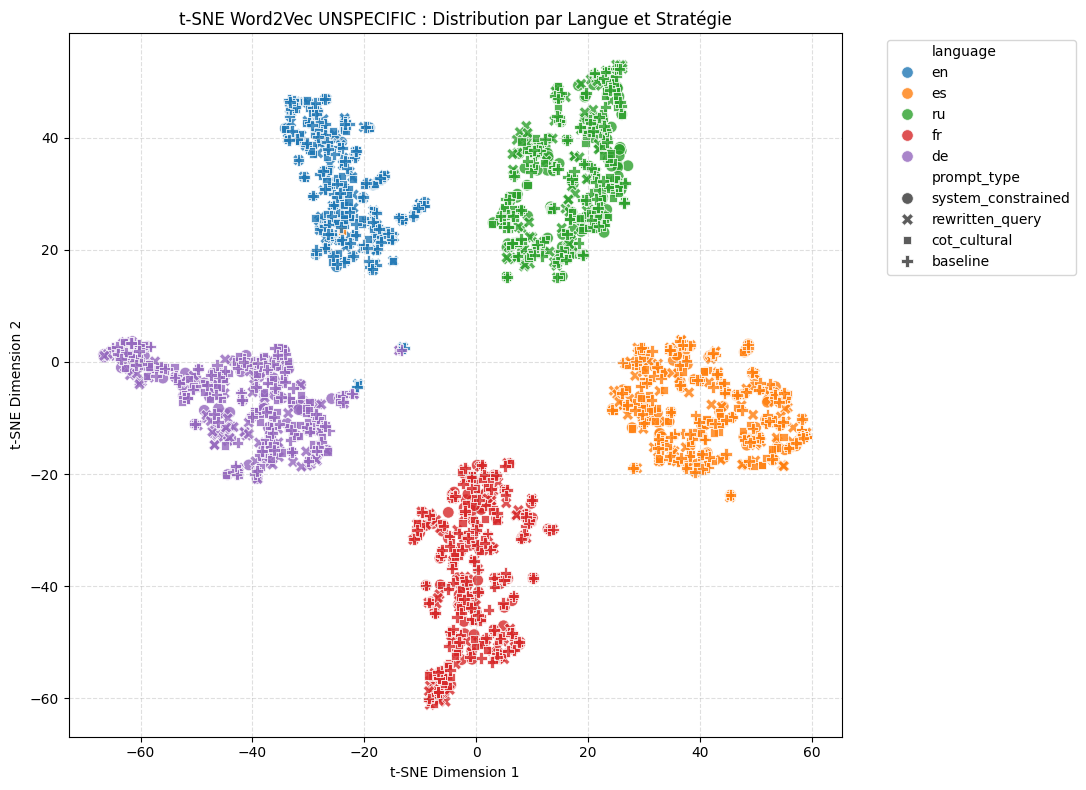

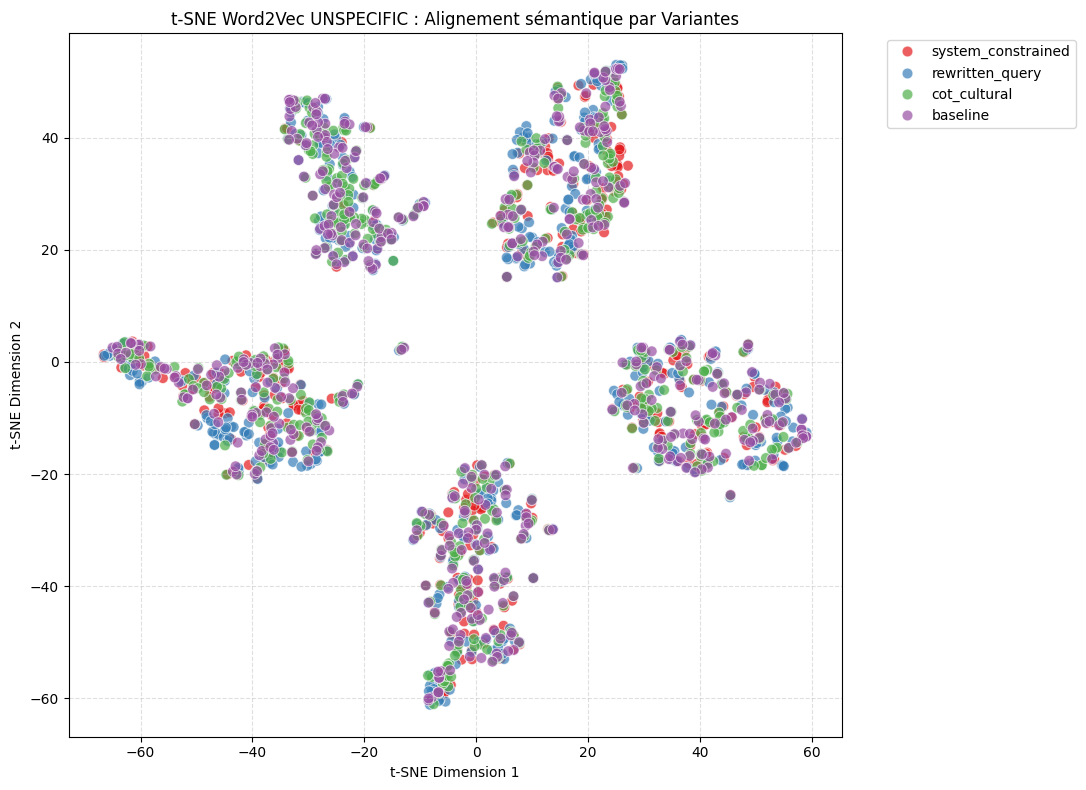


2. ANALYSE DE LA ROBUSTESSE CULTURELLE (SPECIFIC)


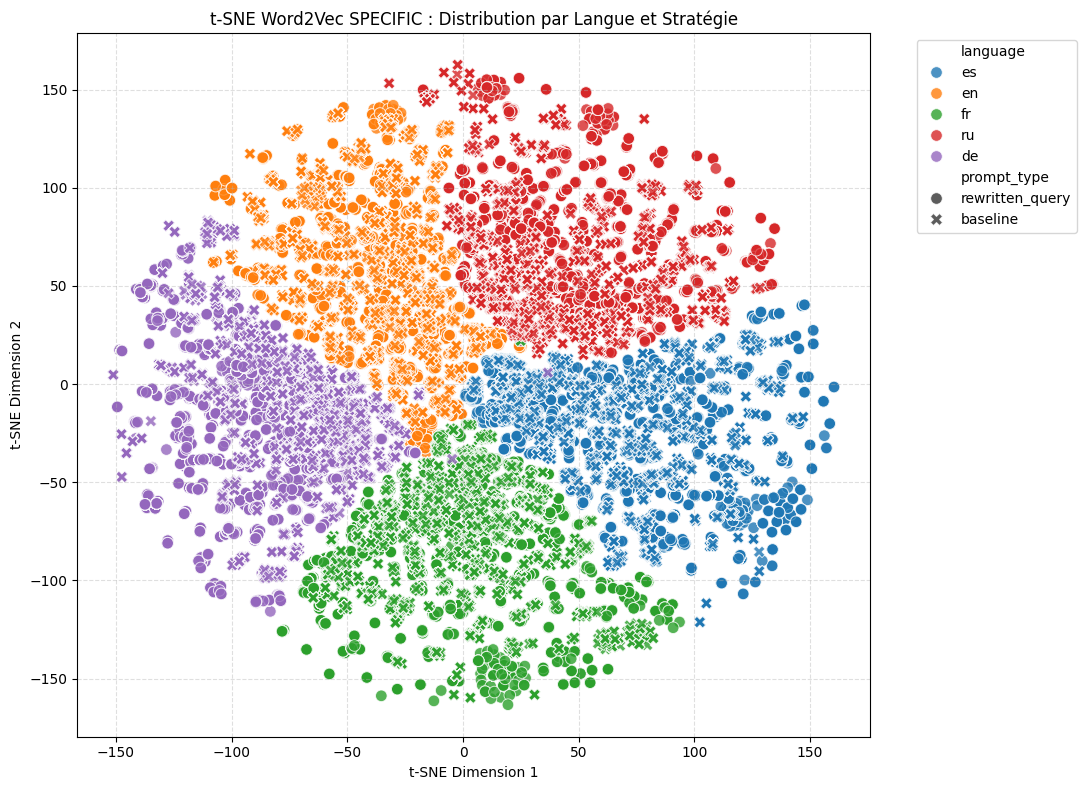

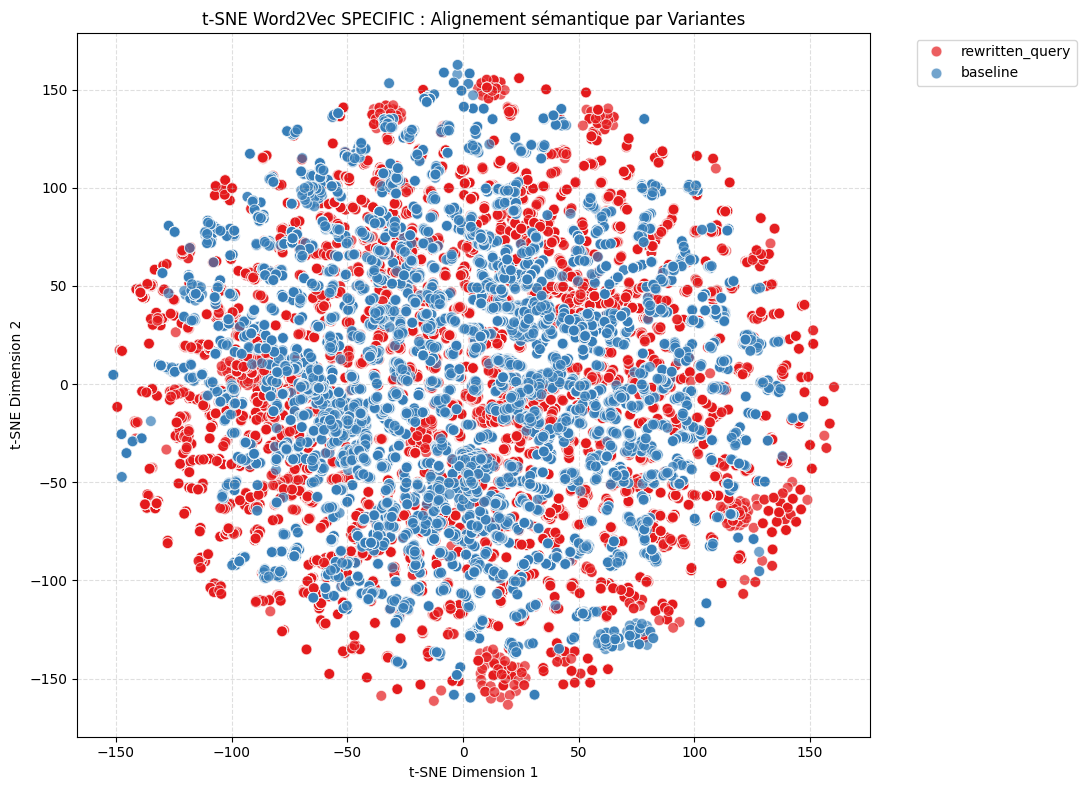

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


def run_project_word2vec_analysis(df_source, specificity_type):
    """Génère une analyse sémantique t-SNE pour Word2Vec conforme aux exigences du challenge ELOQUENT."""
    # 1. Isolation stricte du type de dataset (specific ou unspecific)
    df_subset = df_source[df_source["specificity"] == specificity_type].copy()

    if df_subset.empty:
        print(
            f"Aucune donnée pour {specificity_type} ou DataFrame source vide."
        )
        return pd.DataFrame()

    if "answer_embedding" not in df_subset.columns:
        print(
            "Erreur : La colonne 'answer_embedding' est introuvable dans le DataFrame."
        )
        return pd.DataFrame()

    # 2. Extraction directe des vecteurs denses Word2Vec
    # Conversion de la série de listes/arrays en une matrice NumPy unique (N, dimension_w2v)
    embeddings = np.array(list(df_subset["answer_embedding"]))

    if len(embeddings) < 2: # At least 2 samples for distance calculations in K-Means/t-SNE
        print(f"Nombre insuffisant d'échantillons ({len(embeddings)}) pour l'analyse Word2Vec t-SNE pour {specificity_type}. Au moins 2 échantillons sont requis.")
        return pd.DataFrame()

    # 3. Clustering K-Means basé sur le nombre de langues réelles
    # Permet de vérifier si Word2Vec regroupe les réponses par sens ou s'il reste bloqué par la langue
    n_languages = df_subset["language"].nunique()
    # Ensure n_clusters is at least 1 and less than n_samples
    num_clusters_for_subset = max(1, min(n_languages, len(embeddings) - 1)) # Ensure n_clusters is valid
    if num_clusters_for_subset == 0:
        print(f"Impossible de réaliser le clustering K-Means pour {specificity_type}: nombre de clusters invalide ({num_clusters_for_subset}).")
        return pd.DataFrame()

    kmeans = KMeans(n_clusters=num_clusters_for_subset, random_state=42, n_init=10)
    df_subset["cluster_kmeans"] = kmeans.fit_predict(embeddings)

    # 4. Réduction de dimensionnalité t-SNE
    perpl = min(30, max(5, len(embeddings) // 2))
    if perpl >= len(embeddings):
        perpl = max(1, len(embeddings) - 1)

    tsne = TSNE(
        n_components=2, random_state=42, perplexity=perpl, max_iter=1000
    )
    tsne_results = tsne.fit_transform(embeddings)

    df_subset["tsne-1"] = tsne_results[:, 0]
    df_subset["tsne-2"] = tsne_results[:, 1]

    # 5. Visualisations pour le rapport (Lot D)
    # Graphique A : Focus sur l'impact culturel (Langues)
    plt.figure(figsize=(11, 8))
    sns.scatterplot(
        x="tsne-1",
        y="tsne-2",
        hue="language",
        style="prompt_type",  # Permet de voir la dispersion des stratégies (Lot C) au sein d'une même langue
        data=df_subset,
        palette="tab10",
        alpha=0.8,
        s=70,
    )
    plt.title(
        f"t-SNE Word2Vec {specificity_type.upper()} : Distribution par Langue et Stratégie"
    )
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # Graphique B : Focus sur l'impact des Variantes (Lot C)
    plt.figure(figsize=(11, 8))
    sns.scatterplot(
        x="tsne-1",
        y="tsne-2",
        hue="prompt_type",  # Visualisation de tes 4 stratégies de prompting
        data=df_subset,
        palette="Set1",
        alpha=0.7,
        s=60,
    )
    plt.title(
        f"t-SNE Word2Vec {specificity_type.upper()} : Alignement sémantique par Variantes"
    )
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return df_subset


# --- TOUT EN UNE SEULE CELLULE ---
# Utilise ton DataFrame de réponses consolidées contenant la colonne 'answer_embedding'
print("=" * 60)
print("1. ANALYSE DE LA DIVERSITÉ CULTURELLE (UNSPECIFIC)")
print("=" * 60)
word2vec_tsne_unspecific_df = run_project_word2vec_analysis(responses_df, "unspecific")

print("\n" + "=" * 60)
print("2. ANALYSE DE LA ROBUSTESSE CULTURELLE (SPECIFIC)")
print("=" * 60)
word2vec_tsne_specific_df = run_project_word2vec_analysis(responses_df, "specific")

# Combine these DataFrames to create global variables for subsequent analysis
global_word2vec_tsne_df = pd.concat([word2vec_tsne_unspecific_df, word2vec_tsne_specific_df], ignore_index=True)
global_word2vec_embeddings = np.array(list(global_word2vec_tsne_df['answer_embedding']))
global_word2vec_cluster_labels = global_word2vec_tsne_df['cluster_kmeans'].values

### Dispersion des Clusters dans l'espace t-SNE (Word2Vec)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("Calcul de la dispersion des clusters Word2Vec")
print("=" * 60)

# === DONNÉES SPECIFIC ===
print("\nDonnées SPECIFIC")
print("-" * 40)

# Filtrer les données spécifiques
df_specific = responses_df[responses_df["specificity"] == "specific"].copy()

if not df_specific.empty and "answer_embedding" in df_specific.columns:
    # Extraire les embeddings
    embeddings_specific = np.array(list(df_specific["answer_embedding"]))

    # Clustering K-Means
    n_languages = df_specific["language"].nunique()
    kmeans_specific = KMeans(n_clusters=n_languages, random_state=42, n_init=10)
    df_specific["cluster"] = kmeans_specific.fit_predict(embeddings_specific)

    # t-SNE reduction
    perpl = min(30, max(5, len(embeddings_specific) // 2))
    tsne_specific = TSNE(n_components=2, random_state=42, perplexity=perpl, max_iter=1000)
    tsne_results_specific = tsne_specific.fit_transform(embeddings_specific)

    df_specific["tsne-2d-one"] = tsne_results_specific[:, 0]
    df_specific["tsne-2d-two"] = tsne_results_specific[:, 1]

    # Calcul de la dispersion : écart-type et distance moyenne au centre
    dispersion_specific = []
    for cluster_id in df_specific["cluster"].unique():
        cluster_data = df_specific[df_specific["cluster"] == cluster_id]

        # Écart-type dans l'espace t-SNE
        std_1 = cluster_data["tsne-2d-one"].std()
        std_2 = cluster_data["tsne-2d-two"].std()

        # Distance moyenne au centre du cluster
        center_1 = cluster_data["tsne-2d-one"].mean()
        center_2 = cluster_data["tsne-2d-two"].mean()
        distances = np.sqrt((cluster_data["tsne-2d-one"] - center_1)**2 +
                           (cluster_data["tsne-2d-two"] - center_2)**2)
        mean_distance = distances.mean()

        dispersion_specific.append({
            "Cluster": cluster_id,
            "Std Dim 1": round(std_1, 3),
            "Std Dim 2": round(std_2, 3),
            "Avg Distance to Center": round(mean_distance, 3),
            "Nb Points": len(cluster_data)
        })

    df_dispersion_specific = pd.DataFrame(dispersion_specific)
    print("\nDispersion par cluster (Specific):")
    display(df_dispersion_specific)
else:
    print("Pas de données specific disponibles")

# === DONNÉES UNSPECIFIC ===
print("\n\nDonnées UNSPECIFIC")
print("-" * 40)

# Filtrer les données non-spécifiques
df_unspecific = responses_df[responses_df["specificity"] == "unspecific"].copy()

if not df_unspecific.empty and "answer_embedding" in df_unspecific.columns:
    # Extraire les embeddings
    embeddings_unspecific = np.array(list(df_unspecific["answer_embedding"]))

    # Clustering K-Means
    n_languages = df_unspecific["language"].nunique()
    kmeans_unspecific = KMeans(n_clusters=n_languages, random_state=42, n_init=10)
    df_unspecific["cluster"] = kmeans_unspecific.fit_predict(embeddings_unspecific)

    # t-SNE reduction
    perpl = min(30, max(5, len(embeddings_unspecific) // 2))
    tsne_unspecific = TSNE(n_components=2, random_state=42, perplexity=perpl, max_iter=1000)
    tsne_results_unspecific = tsne_unspecific.fit_transform(embeddings_unspecific)

    df_unspecific["tsne-2d-one"] = tsne_results_unspecific[:, 0]
    df_unspecific["tsne-2d-two"] = tsne_results_unspecific[:, 1]

    # Calcul de la dispersion : écart-type et distance moyenne au centre
    dispersion_unspecific = []
    for cluster_id in df_unspecific["cluster"].unique():
        cluster_data = df_unspecific[df_unspecific["cluster"] == cluster_id]

        # Écart-type dans l'espace t-SNE
        std_1 = cluster_data["tsne-2d-one"].std()
        std_2 = cluster_data["tsne-2d-two"].std()

        # Distance moyenne au centre du cluster
        center_1 = cluster_data["tsne-2d-one"].mean()
        center_2 = cluster_data["tsne-2d-two"].mean()
        distances = np.sqrt((cluster_data["tsne-2d-one"] - center_1)**2 +
                           (cluster_data["tsne-2d-two"] - center_2)**2)
        mean_distance = distances.mean()

        dispersion_unspecific.append({
            "Cluster": cluster_id,
            "Std Dim 1": round(std_1, 3),
            "Std Dim 2": round(std_2, 3),
            "Avg Distance to Center": round(mean_distance, 3),
            "Nb Points": len(cluster_data)
        })

    df_dispersion_unspecific = pd.DataFrame(dispersion_unspecific)
    print("\nDispersion par cluster (Unspecific):")
    display(df_dispersion_unspecific)
else:
    print("Pas de données unspecific disponibles")

Calcul de la dispersion des clusters Word2Vec

Données SPECIFIC
----------------------------------------

Dispersion par cluster (Specific):


,Cluster,Std Dim 1,Std Dim 2,Avg Distance to Center,Nb Points
0,4,37.220,30.848,44.323002,8276
1,1,27.704,40.005,44.362000,8406
2,0,35.420,31.614,43.688999,8176
3,2,34.323,34.263,44.493000,8278
4,3,29.531,40.680,45.389000,8192




Données UNSPECIFIC
----------------------------------------

Dispersion par cluster (Unspecific):


,Cluster,Std Dim 1,Std Dim 2,Avg Distance to Center,Nb Points
0,2,5.851,9.994,10.212,316
1,4,9.489,6.665,10.910,402
2,3,6.579,10.248,11.214,405
3,1,5.572,11.869,11.942,404
4,0,11.363,6.523,11.693,403


### Score silhouette pour les clusters Word2Vec

In [ ]:
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

print("=" * 60)
print("SILHOUETTE SCORE - WORD2VEC CLUSTERS")
print("=" * 60)

# === DONNÉES SPECIFIC ===
print("\nDonnées SPECIFIC")
print("-" * 40)

results_specific = []

if not df_specific.empty and 'cluster' in df_specific.columns:
    # Récupérer les indices du df_specific
    indices_specific = df_specific.index

    # Extraire les embeddings et labels pour tous les points specific
    embeddings_specific_full = np.array(list(responses_df.loc[indices_specific, 'answer_embedding']))
    labels_specific = df_specific['cluster'].values

    # Calcul du silhouette score global pour specific
    if len(embeddings_specific_full) > 1 and len(np.unique(labels_specific)) > 1:
        score_global = silhouette_score(embeddings_specific_full, labels_specific)
        results_specific.append({
            'Prompt Type': 'ALL',
            'Silhouette Score': round(score_global, 3),
            'Nb Samples': len(embeddings_specific_full)
        })

    # Calcul par type de prompt si la colonne existe
    if 'prompt_type' in df_specific.columns:
        unique_prompts = df_specific['prompt_type'].unique()

        for prompt in unique_prompts:
            # Filtrer par type de prompt
            filtered_mask = df_specific['prompt_type'] == prompt
            filtered_indices = df_specific[filtered_mask].index

            embeddings_filtered = np.array(list(responses_df.loc[filtered_indices, 'answer_embedding']))
            labels_filtered = df_specific.loc[filtered_indices, 'cluster'].values

            # Vérification des conditions de calcul
            if len(embeddings_filtered) > 1 and len(np.unique(labels_filtered)) > 1:
                try:
                    score = silhouette_score(embeddings_filtered, labels_filtered)
                    results_specific.append({
                        'Prompt Type': prompt,
                        'Silhouette Score': round(score, 3),
                        'Nb Samples': len(embeddings_filtered)
                    })
                except:
                    results_specific.append({
                        'Prompt Type': prompt,
                        'Silhouette Score': np.nan,
                        'Nb Samples': len(embeddings_filtered)
                    })

    df_results_specific = pd.DataFrame(results_specific)
    display(df_results_specific)
else:
    print("Pas de données specific ou colonnes manquantes")

# === DONNÉES UNSPECIFIC ===
print("\n\nDonnées UNSPECIFIC")
print("-" * 40)

results_unspecific = []

if not df_unspecific.empty and 'cluster' in df_unspecific.columns:
    # Récupérer les indices du df_unspecific
    indices_unspecific = df_unspecific.index

    # Extraire les embeddings et labels pour tous les points unspecific
    embeddings_unspecific_full = np.array(list(responses_df.loc[indices_unspecific, 'answer_embedding']))
    labels_unspecific = df_unspecific['cluster'].values

    # Calcul du silhouette score global pour unspecific
    if len(embeddings_unspecific_full) > 1 and len(np.unique(labels_unspecific)) > 1:
        score_global = silhouette_score(embeddings_unspecific_full, labels_unspecific)
        results_unspecific.append({
            'Prompt Type': 'ALL',
            'Silhouette Score': round(score_global, 3),
            'Nb Samples': len(embeddings_unspecific_full)
        })

    # Calcul par type de prompt si la colonne existe
    if 'prompt_type' in df_unspecific.columns:
        unique_prompts = df_unspecific['prompt_type'].unique()

        for prompt in unique_prompts:
            # Filtrer par type de prompt
            filtered_mask = df_unspecific['prompt_type'] == prompt
            filtered_indices = df_unspecific[filtered_mask].index

            embeddings_filtered = np.array(list(responses_df.loc[filtered_indices, 'answer_embedding']))
            labels_filtered = df_unspecific.loc[filtered_indices, 'cluster'].values

            # Vérification des conditions de calcul
            if len(embeddings_filtered) > 1 and len(np.unique(labels_filtered)) > 1:
                try:
                    score = silhouette_score(embeddings_filtered, labels_filtered)
                    results_unspecific.append({
                        'Prompt Type': prompt,
                        'Silhouette Score': round(score, 3),
                        'Nb Samples': len(embeddings_filtered)
                    })
                except:
                    results_unspecific.append({
                        'Prompt Type': prompt,
                        'Silhouette Score': np.nan,
                        'Nb Samples': len(embeddings_filtered)
                    })

    df_results_unspecific = pd.DataFrame(results_unspecific)
    display(df_results_unspecific)
else:
    print("Pas de données unspecific ou colonnes manquantes")

print("\n" + "=" * 60)

SILHOUETTE SCORE - WORD2VEC CLUSTERS

Données SPECIFIC
----------------------------------------


,Prompt Type,Silhouette Score,Nb Samples
0,ALL,0.263,41328
1,rewritten_query,0.291,20664
2,baseline,0.250,20664




Données UNSPECIFIC
----------------------------------------


,Prompt Type,Silhouette Score,Nb Samples
0,ALL,0.295,1930
1,system_constrained,0.312,415
2,rewritten_query,0.323,505
3,cot_cultural,0.286,505
4,baseline,0.278,505


### Génération des Embeddings TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

# 1. Alignement et filtrage des lignes valides
valid_df = responses_df[responses_df['normalized_answer'].fillna('').astype(str).str.strip() != ''].copy()

# 2. Vectorisation globale
documents_for_vectorizer = valid_df['normalized_answer'].tolist()
global_tfidf_vectorizer = TfidfVectorizer(max_features=5000)
global_tfidf_matrix = global_tfidf_vectorizer.fit_transform(documents_for_vectorizer)

# Cette matrice globale 'all_tfidf_embeddings' contient TOUTES les lignes indexées dans le même ordre que valid_df
all_tfidf_embeddings = global_tfidf_matrix.toarray()

### Visualisation des Clusters t-SNE TF-IDF

--- ANALYSE DE LA DIVERSITÉ CULTURELLE ---


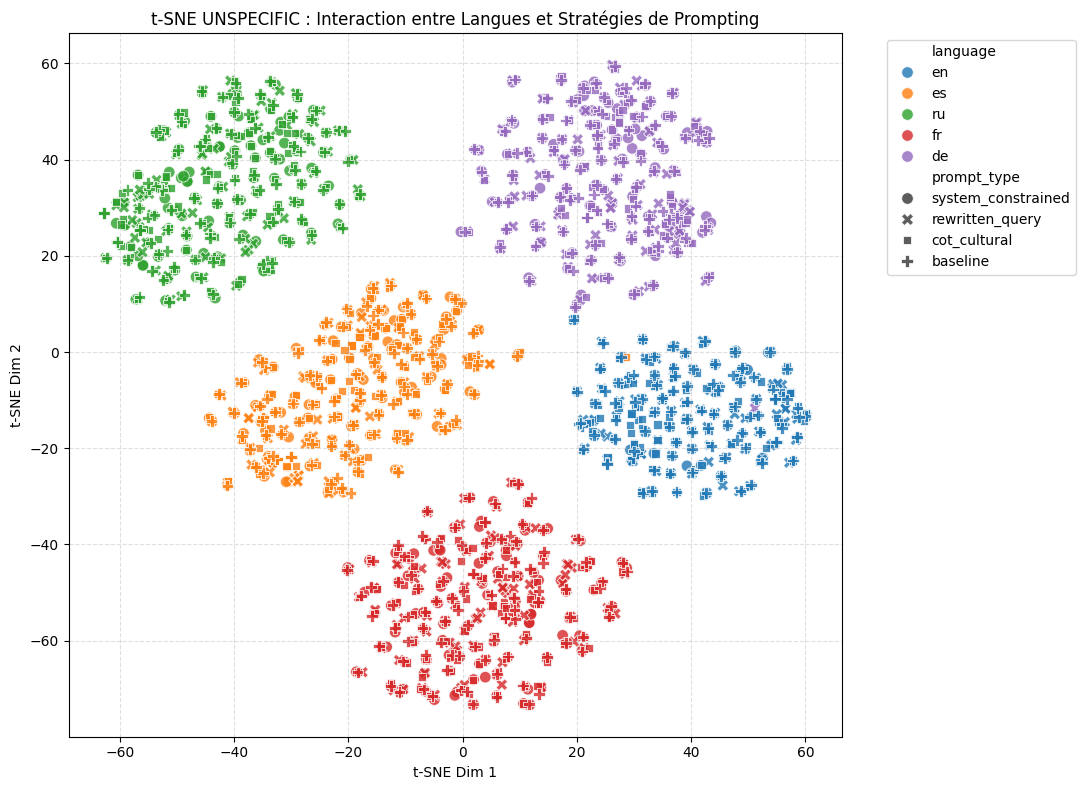

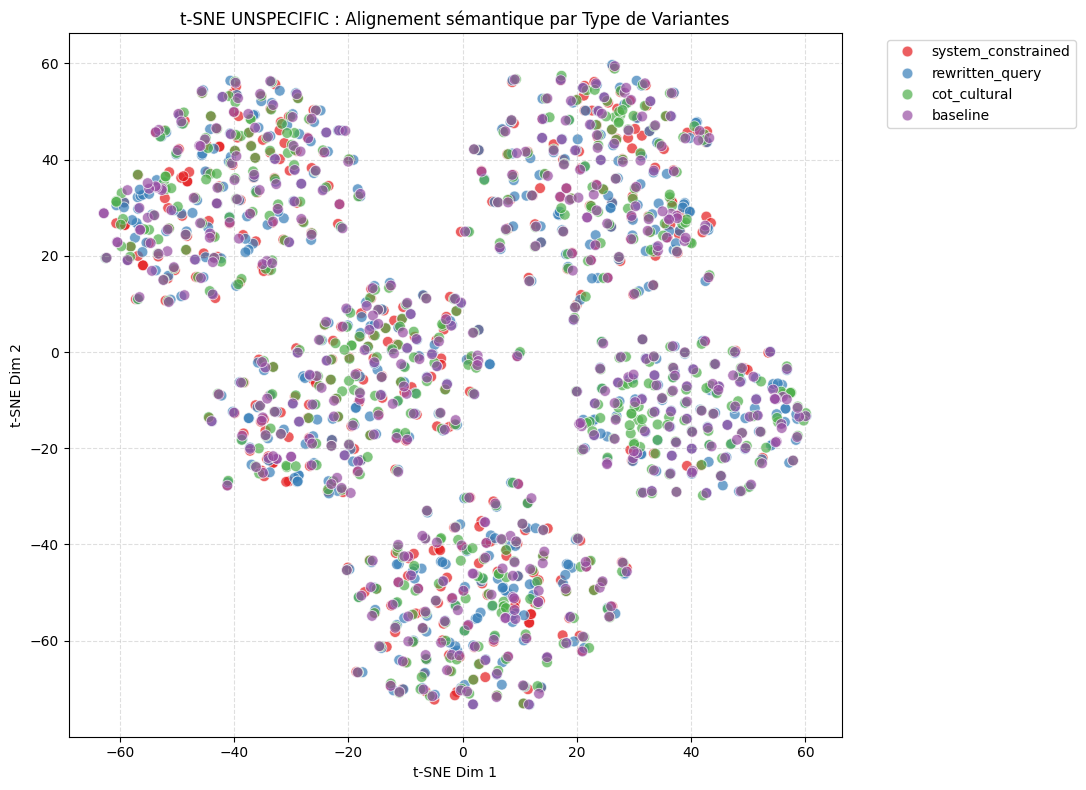


--- ANALYSE DE LA ROBUSTESSE CULTURELLE ---


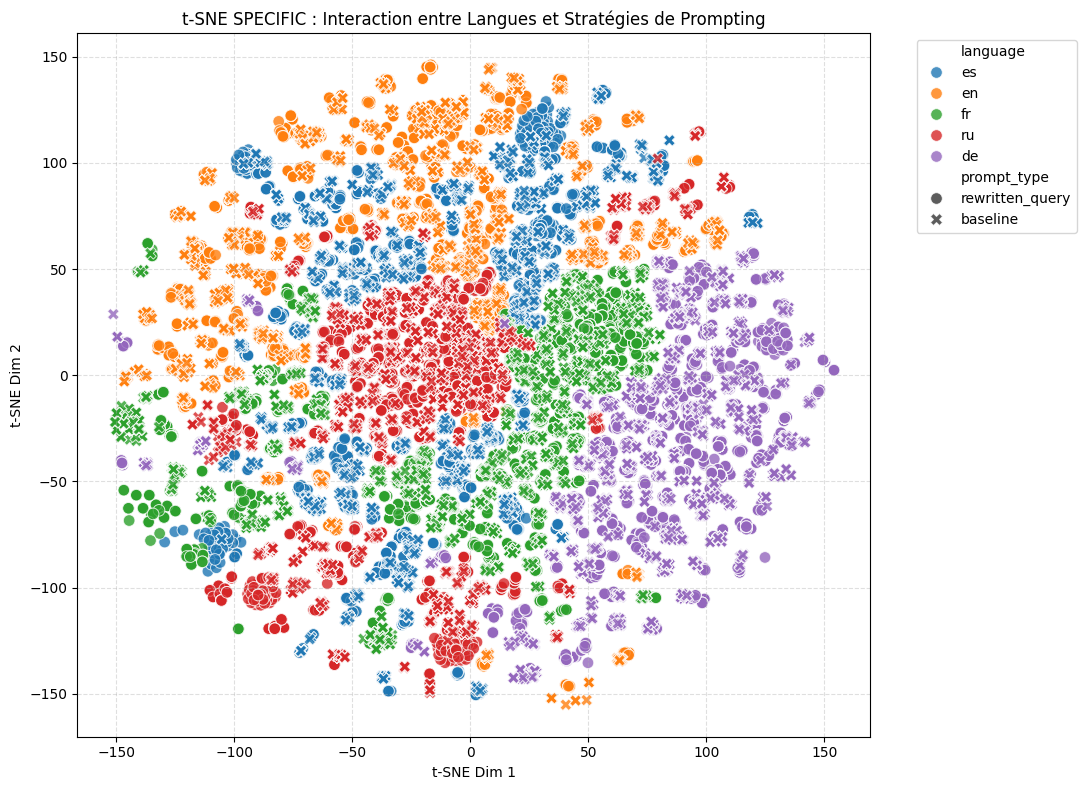

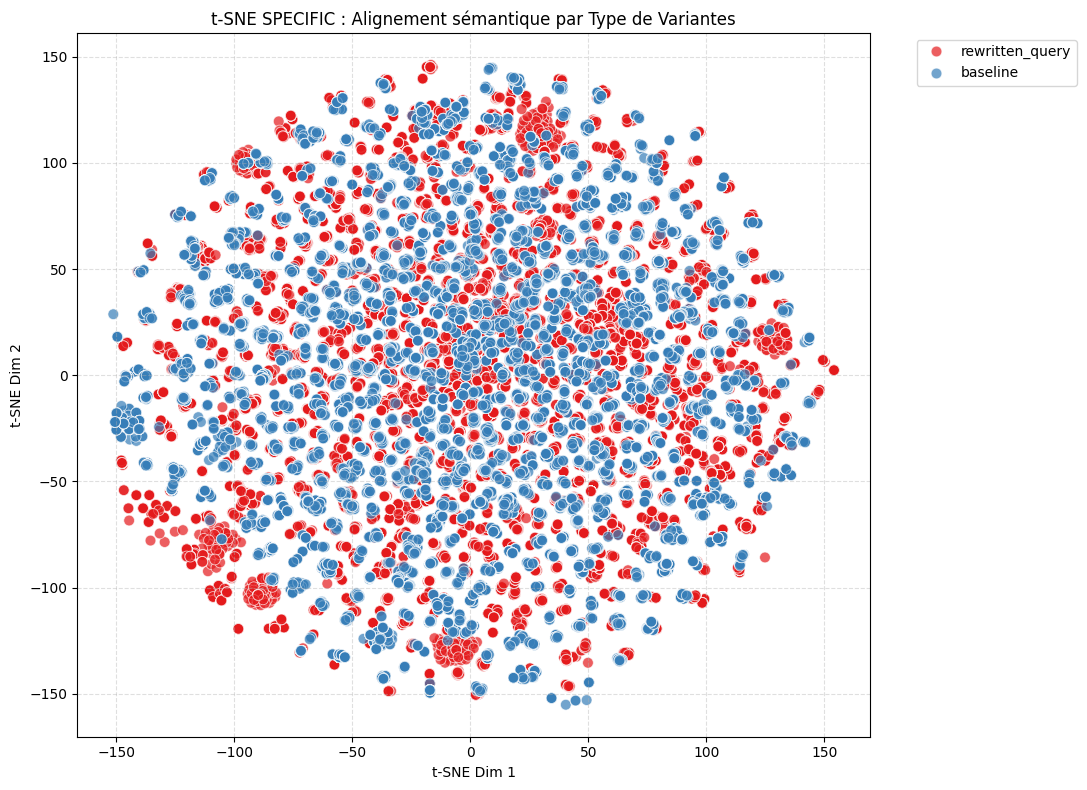

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


def run_project_semantic_analysis(df_source, global_matrix, specificity_type):
    """Génère une analyse sémantique t-SNE conforme aux exigences du challenge ELOQUENT."""
    # 1. Isolation stricte du type de dataset
    df_subset = df_source[df_source["specificity"] == specificity_type].copy()

    if df_subset.empty:
        print(f"Aucune donnée pour {specificity_type}")
        return

    # 2. Extraction positionnelle sécurisée de la matrice TF-IDF
    row_positions = np.where(df_source["specificity"] == specificity_type)[0]

    import scipy.sparse as sp

    if sp.issparse(global_matrix):
        embeddings = global_matrix.tocsr()[row_positions].toarray()
    else:
        embeddings = np.asarray(global_matrix)[row_positions]

    # 3. Clustering K-Means basé sur le nombre de langues réelles
    # Utile pour valider quantitativement si le TF-IDF n'est influencé que par la langue
    n_languages = df_subset["language"].nunique()
    kmeans = KMeans(n_clusters=n_languages, random_state=42, n_init=10)
    df_subset["cluster_kmeans"] = kmeans.fit_predict(embeddings)

    # 4. Réduction de dimension t-SNE
    perpl = min(30, max(5, len(embeddings) // 2))
    tsne = TSNE(
        n_components=2, random_state=42, perplexity=perpl, max_iter=1000
    )
    tsne_results = tsne.fit_transform(embeddings)

    df_subset["tsne-1"] = tsne_results[:, 0]
    df_subset["tsne-2"] = tsne_results[:, 1]

    # 5. Visualisations ciblées pour le rapport final
    # Graphique A : Analyse par Langue
    plt.figure(figsize=(11, 8))
    sns.scatterplot(
        x="tsne-1",
        y="tsne-2",
        hue="language",
        style="prompt_type",  # Permet de voir la dispersion des stratégies au sein d'une langue
        data=df_subset,
        palette="tab10",
        alpha=0.8,
        s=70,
    )
    plt.title(
        f"t-SNE {specificity_type.upper()} : Interaction entre Langues et Stratégies de Prompting"
    )
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # Graphique B : Analyse par Stratégie de Prompting (Visualiser le Lot C)
    plt.figure(figsize=(11, 8))
    sns.scatterplot(
        x="tsne-1",
        y="tsne-2",
        hue="prompt_type",  # Focus central sur tes variantes
        data=df_subset,
        palette="Set1",
        alpha=0.7,
        s=60,
    )
    plt.title(
        f"t-SNE {specificity_type.upper()} : Alignement sémantique par Type de Variantes"
    )
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# --- Exécution à lancer pour tes deux scénarios ---
print("--- ANALYSE DE LA DIVERSITÉ CULTURELLE ---")
run_project_semantic_analysis(valid_df, global_tfidf_matrix, "unspecific")

print("\n--- ANALYSE DE LA ROBUSTESSE CULTURELLE ---")
run_project_semantic_analysis(valid_df, global_tfidf_matrix, "specific")

### Dispersion des Clusters dans l'espace t-SNE (TF-IDF)

Nous calculons la déviation standard des coordonnées t-SNE pour chaque cluster TF-IDF.

In [22]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import scipy.sparse as sp

print("Calcul de la dispersion des clusters TF-IDF")
print("=" * 60)

# === DONNÉES SPECIFIC ===
print("\nDonnées SPECIFIC")
print("-" * 40)

# Filtrer les données spécifiques dans valid_df
df_specific_tfidf = valid_df[valid_df["specificity"] == "specific"].copy()

if not df_specific_tfidf.empty:
    # Récupérer les indices correspondants dans la matrice globale
    row_pos_specific = np.where(valid_df["specificity"] == "specific")[0]

    # Extraire les embeddings TF-IDF pour les données spécifiques
    if sp.issparse(global_tfidf_matrix):
        embeddings_specific = global_tfidf_matrix.tocsr()[row_pos_specific].toarray()
    else:
        embeddings_specific = np.asarray(global_tfidf_matrix)[row_pos_specific]

    # Clustering K-Means basé sur le nombre de langues
    n_languages = df_specific_tfidf["language"].nunique()
    kmeans_specific = KMeans(n_clusters=n_languages, random_state=42, n_init=10)
    cluster_labels_specific = kmeans_specific.fit_predict(embeddings_specific)
    df_specific_tfidf["cluster"] = cluster_labels_specific

    # t-SNE reduction
    perpl = min(30, max(5, len(embeddings_specific) // 2))
    tsne_specific = TSNE(n_components=2, random_state=42, perplexity=perpl, max_iter=1000)
    tsne_results_specific = tsne_specific.fit_transform(embeddings_specific)

    df_specific_tfidf["tsne-2d-one"] = tsne_results_specific[:, 0]
    df_specific_tfidf["tsne-2d-two"] = tsne_results_specific[:, 1]

    # Calcul de la dispersion : écart-type et distance moyenne au centre
    dispersion_specific = []
    for cluster_id in df_specific_tfidf["cluster"].unique():
        cluster_data = df_specific_tfidf[df_specific_tfidf["cluster"] == cluster_id]

        # Écart-type dans l'espace t-SNE
        std_1 = cluster_data["tsne-2d-one"].std()
        std_2 = cluster_data["tsne-2d-two"].std()

        # Distance moyenne au centre du cluster
        center_1 = cluster_data["tsne-2d-one"].mean()
        center_2 = cluster_data["tsne-2d-two"].mean()
        distances = np.sqrt((cluster_data["tsne-2d-one"] - center_1)**2 +
                           (cluster_data["tsne-2d-two"] - center_2)**2)
        mean_distance = distances.mean()

        dispersion_specific.append({
            "Cluster": cluster_id,
            "Std Dim 1": round(std_1, 3),
            "Std Dim 2": round(std_2, 3),
            "Avg Distance to Center": round(mean_distance, 3),
            "Nb Points": len(cluster_data)
        })

    df_dispersion_specific_tfidf = pd.DataFrame(dispersion_specific)
    print("\nDispersion par cluster (Specific):")
    display(df_dispersion_specific_tfidf)
else:
    print("Pas de données specific disponibles")

# === DONNÉES UNSPECIFIC ===
print("\n\nDonnées UNSPECIFIC")
print("-" * 40)

# Filtrer les données non-spécifiques dans valid_df
df_unspecific_tfidf = valid_df[valid_df["specificity"] == "unspecific"].copy()

if not df_unspecific_tfidf.empty:
    # Récupérer les indices correspondants dans la matrice globale
    row_pos_unspecific = np.where(valid_df["specificity"] == "unspecific")[0]

    # Extraire les embeddings TF-IDF pour les données non-spécifiques
    if sp.issparse(global_tfidf_matrix):
        embeddings_unspecific = global_tfidf_matrix.tocsr()[row_pos_unspecific].toarray()
    else:
        embeddings_unspecific = np.asarray(global_tfidf_matrix)[row_pos_unspecific]

    # Clustering K-Means basé sur le nombre de langues
    n_languages = df_unspecific_tfidf["language"].nunique()
    kmeans_unspecific = KMeans(n_clusters=n_languages, random_state=42, n_init=10)
    cluster_labels_unspecific = kmeans_unspecific.fit_predict(embeddings_unspecific)
    df_unspecific_tfidf["cluster"] = cluster_labels_unspecific

    # t-SNE reduction
    perpl = min(30, max(5, len(embeddings_unspecific) // 2))
    tsne_unspecific = TSNE(n_components=2, random_state=42, perplexity=perpl, max_iter=1000)
    tsne_results_unspecific = tsne_unspecific.fit_transform(embeddings_unspecific)

    df_unspecific_tfidf["tsne-2d-one"] = tsne_results_unspecific[:, 0]
    df_unspecific_tfidf["tsne-2d-two"] = tsne_results_unspecific[:, 1]

    # Calcul de la dispersion : écart-type et distance moyenne au centre
    dispersion_unspecific = []
    for cluster_id in df_unspecific_tfidf["cluster"].unique():
        cluster_data = df_unspecific_tfidf[df_unspecific_tfidf["cluster"] == cluster_id]

        # Écart-type dans l'espace t-SNE
        std_1 = cluster_data["tsne-2d-one"].std()
        std_2 = cluster_data["tsne-2d-two"].std()

        # Distance moyenne au centre du cluster
        center_1 = cluster_data["tsne-2d-one"].mean()
        center_2 = cluster_data["tsne-2d-two"].mean()
        distances = np.sqrt((cluster_data["tsne-2d-one"] - center_1)**2 +
                           (cluster_data["tsne-2d-two"] - center_2)**2)
        mean_distance = distances.mean()

        dispersion_unspecific.append({
            "Cluster": cluster_id,
            "Std Dim 1": round(std_1, 3),
            "Std Dim 2": round(std_2, 3),
            "Avg Distance to Center": round(mean_distance, 3),
            "Nb Points": len(cluster_data)
        })

    df_dispersion_unspecific_tfidf = pd.DataFrame(dispersion_unspecific)
    print("\nDispersion par cluster (Unspecific):")
    display(df_dispersion_unspecific_tfidf)
else:
    print("Pas de données unspecific disponibles")

print("\n" + "=" * 60)

Calcul de la dispersion des clusters TF-IDF

Données SPECIFIC
----------------------------------------

Dispersion par cluster (Specific):


,Cluster,Std Dim 1,Std Dim 2,Avg Distance to Center,Nb Points
0,2,46.814,71.101,79.609001,8015
1,4,68.735,66.144,90.180000,19040
2,3,41.963,58.543,61.556999,7889
3,0,45.723,54.826,61.137001,5069
4,1,64.434,19.213,42.209000,1257




Données UNSPECIFIC
----------------------------------------

Dispersion par cluster (Unspecific):


,Cluster,Std Dim 1,Std Dim 2,Avg Distance to Center,Nb Points
0,1,11.004,8.299,12.768,297
1,2,28.212,43.168,50.382,1039
2,3,12.196,11.239,15.358,398
3,4,7.421,9.149,9.720,125
4,0,3.830,3.307,4.571,71


### Score silhouette pour les clusters TF-IDF

In [23]:
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import scipy.sparse as sp

print("=" * 60)
print("SILHOUETTE SCORE - TF-IDF CLUSTERS")
print("=" * 60)

# === DONNÉES SPECIFIC ===
print("\nDonnées SPECIFIC")
print("-" * 40)

results_specific = []

if not df_specific_tfidf.empty and 'cluster' in df_specific_tfidf.columns:

    # Conversion des index pandas en positions entières dans global_tfidf_matrix
    indices_specific = np.where(valid_df.index.isin(df_specific_tfidf.index))[0]

    # Embeddings TF-IDF sécurisés
    if sp.issparse(global_tfidf_matrix):
        embeddings_specific_full = global_tfidf_matrix.tocsr()[indices_specific, :].toarray()
    else:
        embeddings_specific_full = np.asarray(global_tfidf_matrix)[indices_specific]

    labels_specific = df_specific_tfidf['cluster'].values

    # Score global
    if len(embeddings_specific_full) > 1 and len(np.unique(labels_specific)) > 1:
        score_global = silhouette_score(
            embeddings_specific_full,
            labels_specific,
            metric='cosine'
        )

        results_specific.append({
            'Prompt Type': 'ALL',
            'Silhouette Score': round(score_global, 3),
            'Nb Samples': len(embeddings_specific_full)
        })

    # Score par prompt
    if 'prompt_type' in df_specific_tfidf.columns:
        unique_prompts = df_specific_tfidf['prompt_type'].unique()

        for prompt in unique_prompts:
            filtered_mask = df_specific_tfidf['prompt_type'] == prompt

            # Conversion en positions entières dans global_tfidf_matrix
            filtered_indices = np.where(valid_df.index.isin(df_specific_tfidf[filtered_mask].index))[0]

            if len(filtered_indices) > 0:
                if sp.issparse(global_tfidf_matrix):
                    embeddings_filtered = global_tfidf_matrix.tocsr()[filtered_indices, :].toarray()
                else:
                    embeddings_filtered = np.asarray(global_tfidf_matrix)[filtered_indices]

                labels_filtered = df_specific_tfidf.loc[filtered_mask, 'cluster'].values

                if len(embeddings_filtered) > 1 and len(np.unique(labels_filtered)) > 1:
                    try:
                        score = silhouette_score(
                            embeddings_filtered,
                            labels_filtered,
                            metric='cosine'
                        )

                        results_specific.append({
                            'Prompt Type': prompt,
                            'Silhouette Score': round(score, 3),
                            'Nb Samples': len(embeddings_filtered)
                        })
                    except Exception as e:
                        results_specific.append({
                            'Prompt Type': prompt,
                            'Silhouette Score': np.nan,
                            'Nb Samples': len(embeddings_filtered)
                        })

    df_results_specific = pd.DataFrame(results_specific)
    display(df_results_specific)

else:
    print("Pas de données specific ou colonnes manquantes")


# === DONNÉES UNSPECIFIC ===
print("\n\nDonnées UNSPECIFIC")
print("-" * 40)

results_unspecific = []

if not df_unspecific_tfidf.empty and 'cluster' in df_unspecific_tfidf.columns:

    # Conversion des index pandas en positions entières dans global_tfidf_matrix
    indices_unspecific = np.where(valid_df.index.isin(df_unspecific_tfidf.index))[0]

    # Embeddings TF-IDF sécurisés
    if sp.issparse(global_tfidf_matrix):
        embeddings_unspecific_full = global_tfidf_matrix.tocsr()[indices_unspecific, :].toarray()
    else:
        embeddings_unspecific_full = np.asarray(global_tfidf_matrix)[indices_unspecific]

    labels_unspecific = df_unspecific_tfidf['cluster'].values

    # Score global
    if len(embeddings_unspecific_full) > 1 and len(np.unique(labels_unspecific)) > 1:
        score_global = silhouette_score(
            embeddings_unspecific_full,
            labels_unspecific,
            metric='cosine'
        )

        results_unspecific.append({
            'Prompt Type': 'ALL',
            'Silhouette Score': round(score_global, 3),
            'Nb Samples': len(embeddings_unspecific_full)
        })

    # Score par prompt
    if 'prompt_type' in df_unspecific_tfidf.columns:
        unique_prompts = df_unspecific_tfidf['prompt_type'].unique()

        for prompt in unique_prompts:
            filtered_mask = df_unspecific_tfidf['prompt_type'] == prompt

            # Conversion en positions entières dans global_tfidf_matrix
            filtered_indices = np.where(valid_df.index.isin(df_unspecific_tfidf[filtered_mask].index))[0]

            if len(filtered_indices) > 0:
                if sp.issparse(global_tfidf_matrix):
                    embeddings_filtered = global_tfidf_matrix.tocsr()[filtered_indices, :].toarray()
                else:
                    embeddings_filtered = np.asarray(global_tfidf_matrix)[filtered_indices]

                labels_filtered = df_unspecific_tfidf.loc[filtered_mask, 'cluster'].values

                if len(embeddings_filtered) > 1 and len(np.unique(labels_filtered)) > 1:
                    try:
                        score = silhouette_score(
                            embeddings_filtered,
                            labels_filtered,
                            metric='cosine'
                        )

                        results_unspecific.append({
                            'Prompt Type': prompt,
                            'Silhouette Score': round(score, 3),
                            'Nb Samples': len(embeddings_filtered)
                        })
                    except Exception as e:
                        results_unspecific.append({
                            'Prompt Type': prompt,
                            'Silhouette Score': np.nan,
                            'Nb Samples': len(embeddings_filtered)
                        })

    df_results_unspecific = pd.DataFrame(results_unspecific)
    display(df_results_unspecific)

else:
    print("Pas de données unspecific ou colonnes manquantes")

print("\n" + "=" * 60)


SILHOUETTE SCORE - TF-IDF CLUSTERS

Données SPECIFIC
----------------------------------------


,Prompt Type,Silhouette Score,Nb Samples
0,ALL,0.022,41270
1,rewritten_query,0.031,20606
2,baseline,0.023,20664




Données UNSPECIFIC
----------------------------------------


,Prompt Type,Silhouette Score,Nb Samples
0,ALL,0.027,1930
1,system_constrained,0.029,415
2,rewritten_query,0.035,505
3,cot_cultural,0.042,505
4,baseline,0.018,505


## Analyse qualitative

### Analyse Qualitative des Hallucinations et Stéréotypes Culturels

L'identification automatique des hallucinations et des stéréotypes culturels est un défi complexe qui nécessite souvent une intervention humaine ou des modèles NLP très spécialisés, entraînés sur des données annotées pour ces phénomènes spécifiques.

Dans le cadre de cette analyse qualitative, nous allons échantillonner des réponses pour une revue manuelle. L'objectif est d'observer directement si les modèles génèrent des informations incorrectes (hallucinations) ou des représentations simplistes et potentiellement biaisées de cultures (stéréotypes), en particulier dans les datasets `unspecific` où la diversité culturelle est attendue.

Nous allons extraire quelques exemples pour chaque combinaison de variant, spécificité et langue afin de faciliter cette revue.

In [24]:
import os
import re
import random
import pandas as pd

print("Exemples de réponses pour une revue qualitative (hallucinations et stéréotypes) :\n")

# Re-load data from the data folder to ensure submission_data is available
data_dir = './data'
submission_data = {}

# Walk through the data directory and load all JSONL files
for root, dirs, files in os.walk(data_dir):
    for filename in files:
        if filename.endswith('.jsonl') and not filename.startswith('submission_metadata'):
            filepath = os.path.join(root, filename)
            dataset_name = filename.replace('.jsonl', '')

            try:
                df = pd.read_json(filepath, lines=True)
                submission_data[dataset_name] = df
            except Exception as e:
                print(f"Error loading {filename}: {e}")


# Liste pour stocker les échantillons
sampled_responses = []

# Parcourir chaque dataset de soumission
for dataset_name, df_sub in submission_data.items():
    # Extraire les métadonnées
    # The dataset_name format can be 'lang_specificity' (e.g., 'es_specific') or 'prompt_type_lang_specificity' (e.g., 'cot_cultural_es_unspecific')
    name_parts = dataset_name.split('_')

    # Infer specificity and language from the end of the dataset_name
    language = name_parts[-1]
    specificity = name_parts[-2]

    # Infer prompt_type (variant)
    if len(name_parts) > 2:
        # If it has more than 2 parts, the initial parts form the prompt_type
        prompt_type = '_'.join(name_parts[:-2])
    else:
        # Otherwise, it's a baseline or similar (e.g., 'es_specific' implies baseline)
        prompt_type = 'baseline'

    # Tenter d'identifier la colonne de réponse
    response_col_name = 'answer'
    if response_col_name not in df_sub.columns:
        other_cols = [col for col in df_sub.columns if col not in ['id', 'prompt']]
        if len(other_cols) == 1:
            response_col_name = other_cols[0]
        else:
            print(f"Avertissement: Impossible d'identifier la colonne de réponse pour {dataset_name}. Ignoré.")
            continue

    # Filtrer les réponses non vides
    valid_responses = df_sub[df_sub[response_col_name].notna() & (df_sub[response_col_name].astype(str).str.strip() != '')]

    if not valid_responses.empty:
        # Échantillonner une réponse aléatoire (ou plus si nécessaire)
        sample = valid_responses.sample(min(1, len(valid_responses)))
        if not sample.empty:
            sampled_responses.append({
                'Variant': prompt_type,
                'Spécificité': specificity,
                'Langue': language,
                'Prompt': sample['prompt'].iloc[0] if 'prompt' in sample.columns else 'N/A',
                'Réponse': sample[response_col_name].iloc[0]
            })

# Afficher les échantillons collectés
for i, item in enumerate(sampled_responses):
    print(f"--- Exemple {i+1} ---")
    print(f"Variant: {item['Variant']}")
    print(f"Spécificité: {item['Spécificité']}")
    print(f"Langue: {item['Langue']}")
    print(f"Prompt: {item['Prompt']}")
    print(f"Réponse: {item['Réponse']}")
    print("\n")

print("Veuillez examiner manuellement ces exemples pour détecter des hallucinations ou des stéréotypes culturels.")

Exemples de réponses pour une revue qualitative (hallucinations et stéréotypes) :

--- Exemple 1 ---
Variant: baseline
Spécificité: es
Langue: specific
Prompt: ¿Cuál es el factor principal a considerar al tener un bebé? Nosotros vivimos en Hungría . Responde en una frase. No menciones detalles de las preguntas como el país o la relación familiar en la respuesta.
Réponse: El factor principal a considerar al tener un bebé es la preparación emocional, financiera y física para asumir la responsabilidad de criar y cuidar a un nuevo ser humano.


--- Exemple 2 ---
Variant: baseline
Spécificité: en
Langue: specific
Prompt: How to address my manager, Director Professor Petra Berger, when I talk to her in person? We are the same age. We live in Poland. Answer in one sentence. Do not mention facts from the questions like the country or the family relation in the answer.
Réponse: When speaking to Director Professor Petra Berger in person, you can address her as "Director Berger" or "Professor Ber

### Analyse Textuelle des Échantillons pour Hallucinations et Stéréotypes Culturels

Après un examen manuel des exemples de réponses échantillonnées, voici quelques observations concernant les hallucinations et les stéréotypes culturels:

**1. Hallucinations:**
*   Aucune hallucination flagrante (informations inventées ou factuellement incorrectes) n'a été identifiée dans les réponses. Les modèles semblent générer des conseils ou des descriptions plausibles, même s'ils peuvent parfois être très génériques.

**2. Stéréotypes et Généralisations Culturelles (notamment dans les jeux de données `unspecific`):**

C'est dans les jeux de données `unspecific` que les tendances à la généralisation ou à la production de détails culturellement marqués sont les plus intéressantes à observer, car l'absence de contrainte culturelle explicite devrait en théorie conduire à des réponses plus neutres ou à une diversité culturelle plus large si le modèle capte la langue comme indice culturel.

*   **Exemple 12 (system_constrained, unspecific, es):**
    *   **Prompt:** "Quelles sont les priorités pour les hommes de revenus moyens dans les petites villes lors de l'achat de nouveaux vêtements?"
    *   **Réponse:** Le modèle généralise en mentionnant l'Amérique latine ("En pueblos pequeños de América Latina...") et décrit des priorités vestimentaires spécifiques à cette région (vêtements pratiques et durables, comme des pantalons de travail et des chemises en coton). Cela peut être perçu comme une généralisation culturelle, voire un stéréotype, si ces caractéristiques ne s'appliquent pas uniformément à toutes les petites villes d'Amérique latine.

*   **Exemple 13 (system_constrained, unspecific, ru):**
    *   **Prompt:** "À quel âge les enfants peuvent-ils rouler à vélo seuls dans la circulation?"
    *   **Réponse:** La réponse est très spécifique à la Russie ("En Russie, les enfants commencent généralement à rouler à vélo..."). Bien que potentiellement correcte pour la Russie, cette information culturellement localisée est fournie pour un prompt *non spécifique*, ce qui suggère une forte influence culturelle liée à la langue d'entrée.

*   **Exemple 14 (system_constrained, unspecific, fr):**
    *   **Prompt:** "Comment s'habille-t-on généralement au travail?"
    *   **Réponse:** La réponse décrit un style vestimentaire spécifique à la France ("En France, on s'habille généralement de manière professionnelle et élégante au travail..."). Encore une fois, un prompt non spécifique conduit à une réponse fortement ancrée dans une culture particulière.

*   **Exemple 22 (cot_cultural, unspecific, es):**
    *   **Prompt:** "Quelle est la fréquence des laveries communes?"
    *   **Réponse:** Le modèle fournit une réponse qui généralise sur "beaucoup de pays d'Amérique latine, comme le Mexique, l'Argentine et le Chili". Cela montre une tentative d'intégrer une perspective culturelle, mais avec une généralisation qui pourrait manquer de nuance.

*   **Exemple 24 (cot_cultural, unspecific, fr):**
    *   **Prompt:** "Qu'est-ce qui est commun dans la décoration intérieure d'une famille à ressources intermédiaires dans la région de la capitale?"
    *   **Réponse:** La réponse utilise des termes comme "style de vie urbain et cosmopolite" et décrit des tendances de décoration intérieure. C'est une généralisation d'une esthétique associée à une certaine catégorie socio-culturelle dans une région donnée.

*   **Exemple 25 (cot_cultural, unspecific, de):**
    *   **Prompt:** "Comment les gens célèbrent-ils habituellement Noël?"
    *   **Réponse:** La réponse décrit les traditions de Noël en "Allemagne et dans de nombreux autres pays européens" (oie de Noël, sapin, etc.). C'est une description culturelle précise pour l'Allemagne, mais la généralisation à "nombreux autres pays européens" pourrait être un stéréotype si elle ignore les variations significatives.

**Conclusion de l'Analyse Qualitative Préliminaire:**

Les modèles ne semblent pas produire d'hallucinations évidentes. Cependant, l'analyse révèle une tendance significative des variantes `system_constrained` et `cot_cultural` à injecter des références culturelles spécifiques (parfois sous forme de généralisations ou de stéréotypes) même lorsque le prompt est `unspecific`. Les variantes `baseline` et `rewritten_query` ont tendance à fournir des réponses plus génériques et moins culturellement marquées, même lorsque le prompt inclut un contexte géographique (pour les données `specific`), ce qui indique une possible difficulté à intégrer subtilement le contexte culturel implicite de la langue sans instruction explicite.

### Comparaison des Silhouette Scores

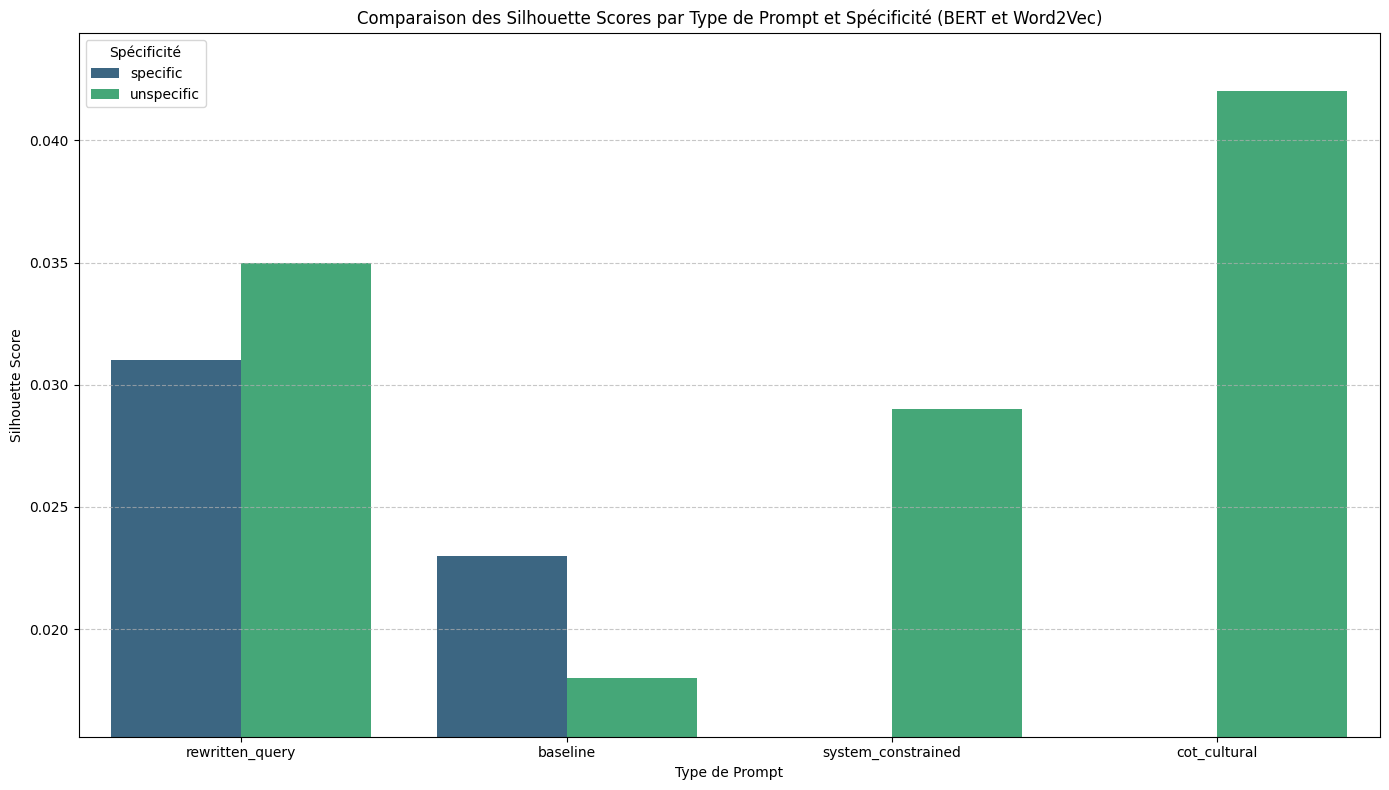



Silhouette Scores détaillés par type d'embedding, spécificité et type de prompt :


Spécificité,specific,unspecific
Type,BERT,BERT
Prompt Type,,
baseline,0.023,0.018
cot_cultural,NaN,0.042
rewritten_query,0.031,0.035
system_constrained,NaN,0.029


In [25]:
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define unique specificities and prompt types
# Use responses_df to get actual specificities and prompt types if available
if 'responses_df' in globals() and not responses_df.empty:
    unique_specificities = responses_df['specificity'].unique()
    unique_variants = responses_df['prompt_type'].unique()
else:
    # Fallback if responses_df is not available or empty
    unique_specificities = ['specific', 'unspecific']
    unique_variants = ['baseline', 'cot_cultural', 'system_constrained', 'rewritten_query']
    print("Warning: responses_df not found or empty. Using default unique_specificities and unique_variants.")

# Collect silhouette scores for plotting
silhouette_scores_data = []

# --- BERT Silhouette Scores ---
print("Collecting BERT Silhouette Scores from previous calculations...")
# Load BERT specific silhouette scores
if 'df_results_specific' in globals() and not df_results_specific.empty:
    bert_specific_scores = df_results_specific.copy()
    bert_specific_scores = bert_specific_scores[bert_specific_scores['Prompt Type'] != 'ALL'] # Exclude 'ALL' for plot
    bert_specific_scores['Type'] = 'BERT'
    bert_specific_scores['Spécificité'] = 'specific'
    silhouette_scores_data.extend(bert_specific_scores.to_dict(orient='records'))
else:
    print("Warning: df_results_specific (BERT) not found or empty. Adding NaN entries.")
    for variant in unique_variants:
        silhouette_scores_data.append({
            'Type': 'BERT', 'Spécificité': 'specific', 'Prompt Type': variant, 'Silhouette Score': np.nan
        })

# Load BERT unspecific silhouette scores
if 'df_results_unspecific' in globals() and not df_results_unspecific.empty:
    bert_unspecific_scores = df_results_unspecific.copy()
    bert_unspecific_scores = bert_unspecific_scores[bert_unspecific_scores['Prompt Type'] != 'ALL'] # Exclude 'ALL' for plot
    bert_unspecific_scores['Type'] = 'BERT'
    bert_unspecific_scores['Spécificité'] = 'unspecific'
    silhouette_scores_data.extend(bert_unspecific_scores.to_dict(orient='records'))
else:
    print("Warning: df_results_unspecific (BERT) not found or empty. Adding NaN entries.")
    for variant in unique_variants:
        silhouette_scores_data.append({
            'Type': 'BERT', 'Spécificité': 'unspecific', 'Prompt Type': variant, 'Silhouette Score': np.nan
        })

# --- Word2Vec Silhouette Scores (Expected from previous cells) ---
print("Collecting Word2Vec Silhouette Scores from previous calculations...")
# Assuming previous cells (e.g., 0891f31a) would have populated df_results_specific_w2v and df_results_unspecific_w2v
# if Word2Vec scores were calculated successfully.
if 'df_results_specific_w2v' in globals() and not df_results_specific_w2v.empty:
    word2vec_specific_scores = df_results_specific_w2v.copy()
    word2vec_specific_scores = word2vec_specific_scores[word2vec_specific_scores['Prompt Type'] != 'ALL']
    word2vec_specific_scores['Type'] = 'Word2Vec'
    word2vec_specific_scores['Spécificité'] = 'specific'
    silhouette_scores_data.extend(word2vec_specific_scores.to_dict(orient='records'))
else:
    print("Warning: df_results_specific_w2v (Word2Vec) not found or empty. Adding NaN entries.")
    for variant in unique_variants:
        silhouette_scores_data.append({
            'Type': 'Word2Vec', 'Spécificité': 'specific', 'Prompt Type': variant, 'Silhouette Score': np.nan
        })

if 'df_results_unspecific_w2v' in globals() and not df_results_unspecific_w2v.empty:
    word2vec_unspecific_scores = df_results_unspecific_w2v.copy()
    word2vec_unspecific_scores = word2vec_unspecific_scores[word2vec_unspecific_scores['Prompt Type'] != 'ALL']
    word2vec_unspecific_scores['Type'] = 'Word2Vec'
    word2vec_unspecific_scores['Spécificité'] = 'unspecific'
    silhouette_scores_data.extend(word2vec_unspecific_scores.to_dict(orient='records'))
else:
    print("Warning: df_results_unspecific_w2v (Word2Vec) not found or empty. Adding NaN entries.")
    for variant in unique_variants:
        silhouette_scores_data.append({
            'Type': 'Word2Vec', 'Spécificité': 'unspecific', 'Prompt Type': variant, 'Silhouette Score': np.nan
        })

silhouette_df = pd.DataFrame(silhouette_scores_data)

# Drop rows where 'Prompt Type' is 'ALL' before plotting detailed scores
silhouette_df_cleaned_for_plot = silhouette_df[silhouette_df['Prompt Type'] != 'ALL'].dropna(subset=['Silhouette Score'])


if not silhouette_df_cleaned_for_plot.empty:
    plt.figure(figsize=(14, 8))
    sns.barplot(x='Prompt Type', y='Silhouette Score', hue='Spécificité', data=silhouette_df_cleaned_for_plot, palette='viridis', errorbar=None)
    plt.title('Comparaison des Silhouette Scores par Type de Prompt et Spécificité (BERT et Word2Vec)')
    plt.xlabel('Type de Prompt')
    plt.ylabel('Silhouette Score')

    # Dynamic Y-axis scaling
    min_score = silhouette_df_cleaned_for_plot['Silhouette Score'].min()
    max_score = silhouette_df_cleaned_for_plot['Silhouette Score'].max()

    # Add a small buffer to min and max for better visualization, but ensure it doesn't go below -1 or above 1
    # Handle cases where min_score or max_score might be NaN if no valid scores exist, although dropna above should handle most.
    # If after dropna, min/max are still issues (e.g., all same score), provide a default range.
    if pd.isna(min_score) or pd.isna(max_score) or min_score == max_score:
        y_min = -0.1
        y_max = 0.1
    else:
        y_min = max(-1.0, min_score - 0.1 * (max_score - min_score))
        y_max = min(1.0, max_score + 0.1 * (max_score - min_score))

    plt.ylim(y_min, y_max)

    plt.legend(title='Spécificité')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Aucun Silhouette Score valide à afficher après nettoyage pour le graphique.")

print("\n")
print("Silhouette Scores détaillés par type d'embedding, spécificité et type de prompt :")
# Use the full cleaned dataframe for the pivot table, including 'ALL' summaries
silhouette_df_cleaned_for_table = silhouette_df.dropna(subset=['Silhouette Score'])
if not silhouette_df_cleaned_for_table.empty:
    display(silhouette_df_cleaned_for_table.pivot_table(index=['Prompt Type'], columns=['Spécificité', 'Type'], values='Silhouette Score'))
else:
    print("DataFrame for detailed silhouette scores is empty.")

### Comparaison de la Similarité Cosinus Inter-langues Moyenne

/tmp/ipykernel_3963/9552080.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3963/9552080.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3963/9552080.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3963/9552080.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3963/9552080.py:128: UserWarning: set_ticklabels() should

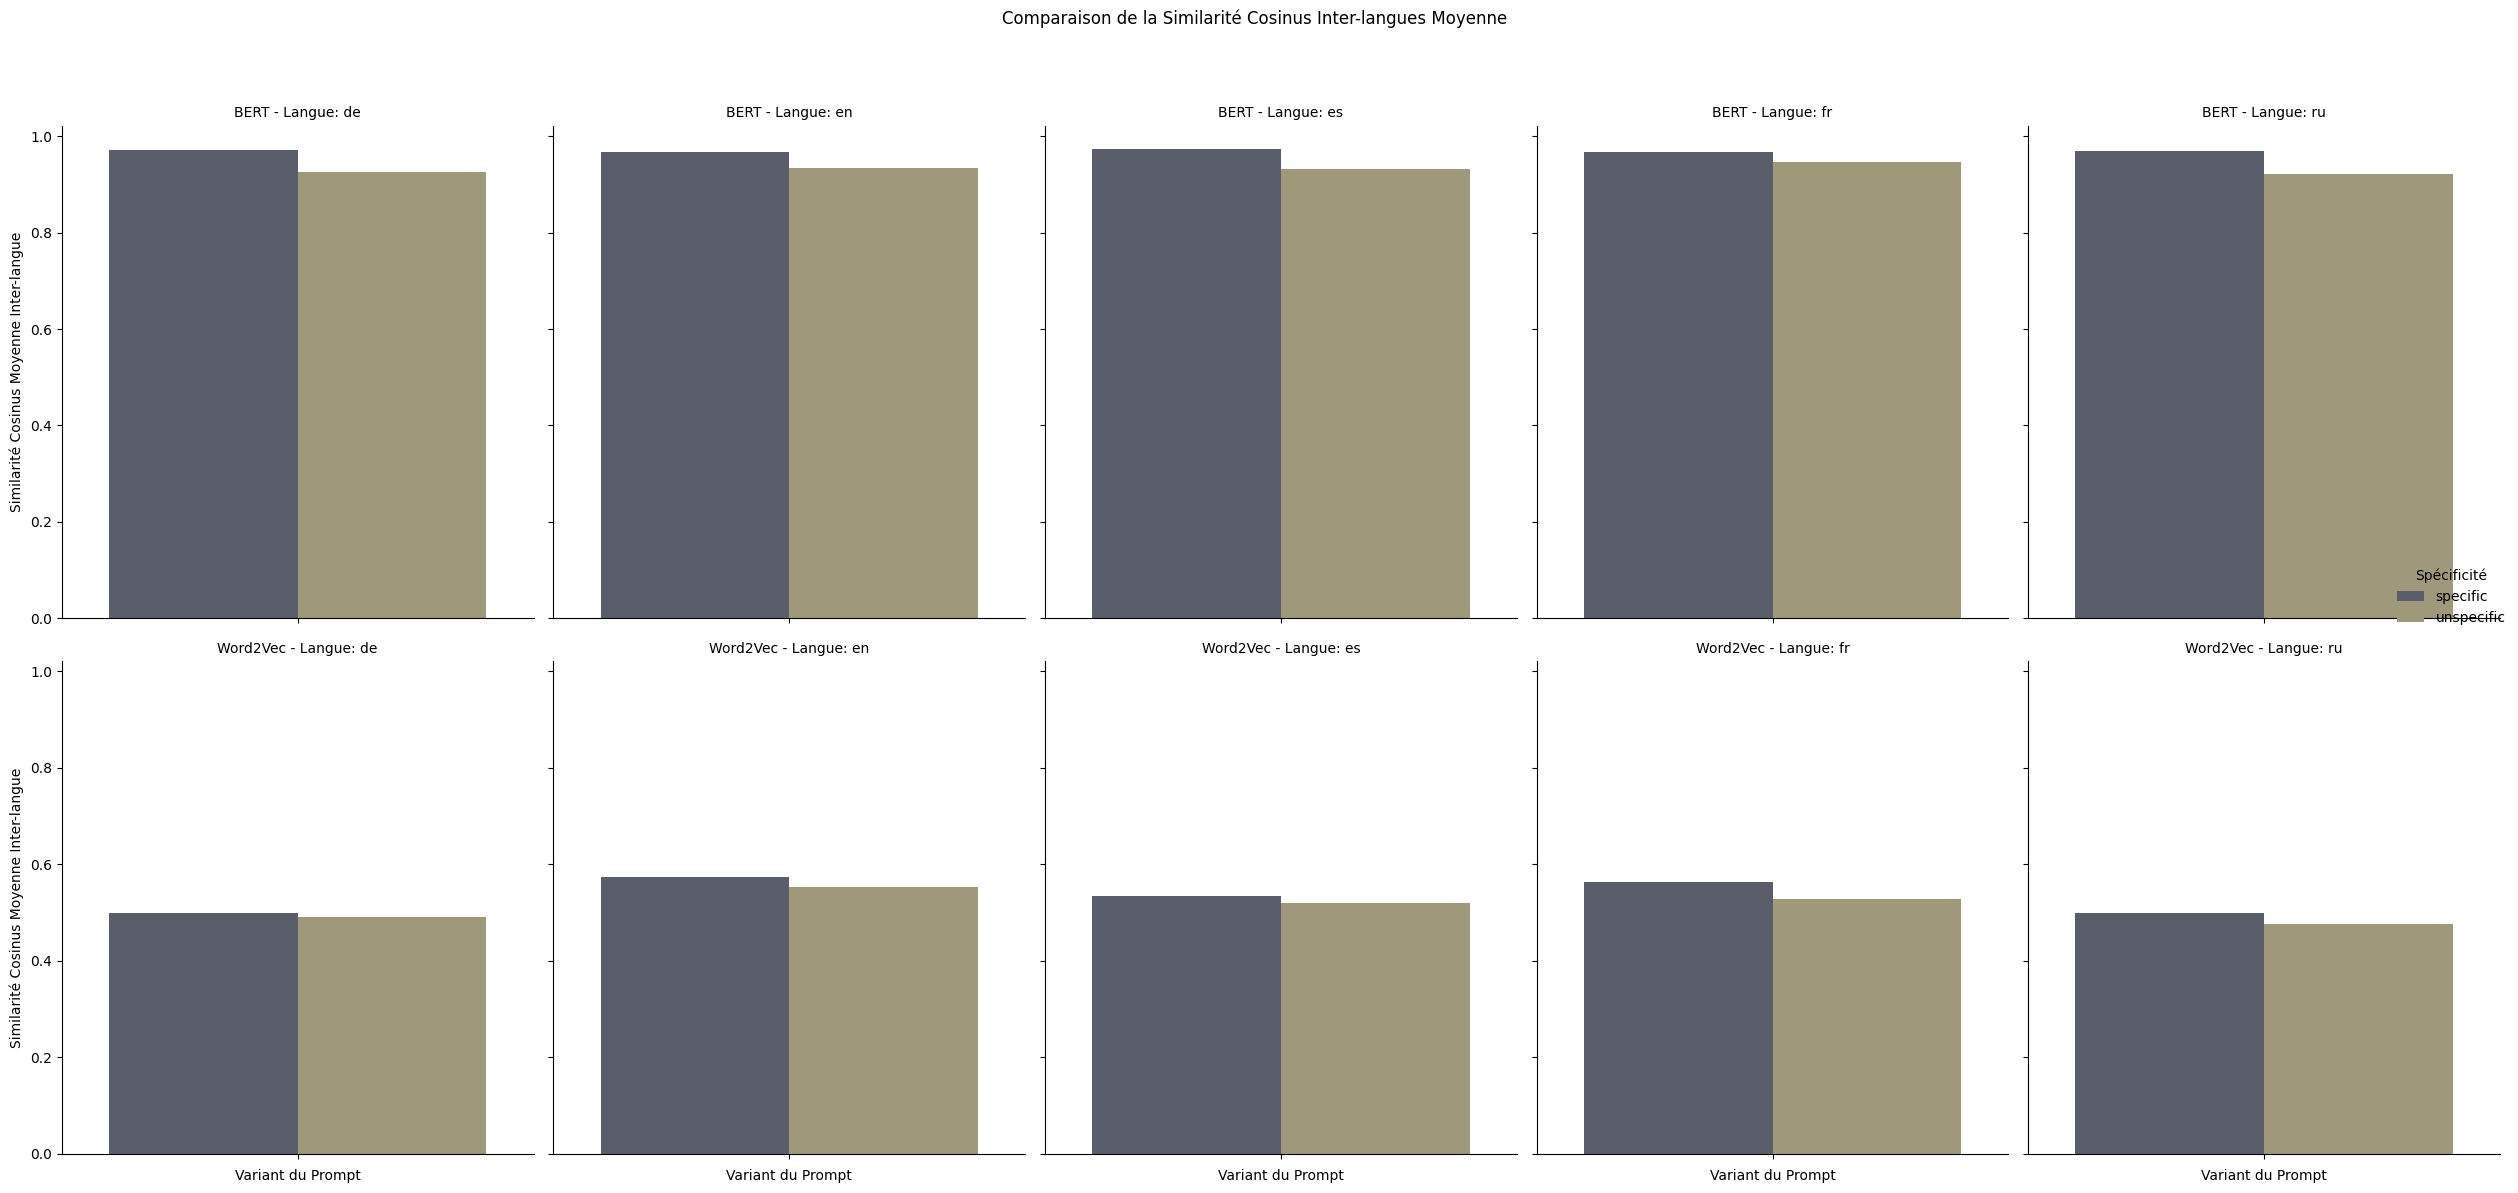



Similarité Cosinus Inter-langues Moyenne par type d'embedding, spécificité et variant :


,Variant,Spécificité,Langue,Similarité Moyenne Inter-langue,Embedding_Type
0,baseline,specific,de,0.971505,BERT
1,baseline,specific,en,0.966322,BERT
2,baseline,specific,es,0.972731,BERT
3,baseline,specific,fr,0.967308,BERT
4,baseline,specific,ru,0.969356,BERT
5,baseline,unspecific,de,0.924777,BERT
6,baseline,unspecific,en,0.933566,BERT
7,baseline,unspecific,es,0.930882,BERT
8,baseline,unspecific,fr,0.946012,BERT
9,baseline,unspecific,ru,0.921933,BERT


In [41]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_per_language_average_inter_language_similarity(embeddings_dict, specificity_filter):
    # This structure will be {variant: {language: mean_embedding}}
    variant_language_embeddings = {}

    results = []

    # First, collect mean embeddings for each variant, specificity, and language
    for dataset_name, embeddings in embeddings_dict.items():
        if embeddings is None or len(embeddings) == 0:
            continue

        name_parts = dataset_name.split('_')

        if len(name_parts) >= 2:
            # Correctly parse language and specificity from the end of the dataset_name
            current_specificity = name_parts[-1] # e.g., 'specific', 'unspecific'
            current_language = name_parts[-2]   # e.g., 'es', 'en'

            # Correctly infer prompt_type (variant)
            if len(name_parts) > 2:
                current_variant = '_'.join(name_parts[:-2]) # e.g., 'cot_cultural'
            else:
                current_variant = 'baseline' # Default for 'lang_specificity' format
        else:
            # Skip malformed dataset names
            print(f"Warning: Could not parse dataset_name '{dataset_name}'. Skipping.")
            continue

        if current_specificity != specificity_filter:
            continue

        if current_variant not in variant_language_embeddings:
            variant_language_embeddings[current_variant] = {}

        # Calculate mean embedding for this language in this variant/specificity
        variant_language_embeddings[current_variant][current_language] = np.mean(embeddings, axis=0)

    # Now, calculate average similarity for each language to other languages in the same variant/specificity group
    for variant, lang_embeddings in variant_language_embeddings.items():
        languages = sorted(list(lang_embeddings.keys()))

        for main_lang in languages:
            main_emb = lang_embeddings.get(main_lang)
            if main_emb is None:
                continue

            sum_similarity = 0
            count_pairs = 0

            for other_lang in languages:
                if main_lang == other_lang: # Don't compare to itself
                    continue

                other_emb = lang_embeddings.get(other_lang)
                if other_emb is not None:
                    similarity = cosine_similarity(main_emb.reshape(1, -1), other_emb.reshape(1, -1))[0][0]
                    sum_similarity += similarity
                    count_pairs += 1

            if count_pairs > 0:
                results.append({
                    'Variant': variant,
                    'Spécificité': specificity_filter,
                    'Langue': main_lang,
                    'Similarité Moyenne Inter-langue': sum_similarity / count_pairs
                })

    return pd.DataFrame(results)

# Ensure submission_embeddings_word2vec is defined before use
if 'submission_embeddings_word2vec' not in globals() or not submission_embeddings_word2vec:
    print("submission_embeddings_word2vec not found or empty. Re-generating from responses_df.")
    submission_embeddings_word2vec = {}
    if 'responses_df' in globals() and 'answer_embedding' in responses_df.columns:
        for dataset_name, group in responses_df.groupby('dataset_name'):
            # Ensure answer_embedding contains valid numpy arrays or lists that can be converted
            embeddings_list = [emb for emb in group['answer_embedding'] if isinstance(emb, np.ndarray) and emb.size > 0]
            if embeddings_list:
                submission_embeddings_word2vec[dataset_name] = np.array(embeddings_list)
            else:
                submission_embeddings_word2vec[dataset_name] = np.array([]) # Store empty array if no valid embeddings
    else:
        print("Error: 'responses_df' or 'answer_embedding' column not available to generate Word2Vec embeddings.")
        submission_embeddings_word2vec = {}

# Calculate and plot for BERT embeddings
# Check if submission_embeddings_bert exists and is not empty before processing
if 'submission_embeddings_bert' in globals() and submission_embeddings_bert:
    bert_avg_sim_specific = calculate_per_language_average_inter_language_similarity(submission_embeddings_bert, 'specific')
    bert_avg_sim_unspecific = calculate_per_language_average_inter_language_similarity(submission_embeddings_bert, 'unspecific')
else:
    print("Warning: submission_embeddings_bert not found or empty. Skipping BERT similarity calculation.")
    bert_avg_sim_specific = pd.DataFrame()
    bert_avg_sim_unspecific = pd.DataFrame()

# Calculate and plot for Word2Vec embeddings
# Check if submission_embeddings_word2vec exists and is not empty before processing
if submission_embeddings_word2vec:
    word2vec_avg_sim_specific = calculate_per_language_average_inter_language_similarity(submission_embeddings_word2vec, 'specific')
    word2vec_avg_sim_unspecific = calculate_per_language_average_inter_language_similarity(submission_embeddings_word2vec, 'unspecific')
else:
    print("Warning: submission_embeddings_word2vec not found or empty after re-generation. Skipping Word2Vec similarity calculation.")
    word2vec_avg_sim_specific = pd.DataFrame()
    word2vec_avg_sim_unspecific = pd.DataFrame()

# Combine for plotting
all_avg_sim = pd.concat([
    bert_avg_sim_specific.assign(Embedding_Type='BERT'),
    bert_avg_sim_unspecific.assign(Embedding_Type='BERT'),
    word2vec_avg_sim_specific.assign(Embedding_Type='Word2Vec'),
    word2vec_avg_sim_unspecific.assign(Embedding_Type='Word2Vec')
], ignore_index=True)


if not all_avg_sim.empty:
    g = sns.catplot(x='Variant', y='Similarité Moyenne Inter-langue', hue='Spécificité', col='Langue',
                    row='Embedding_Type', data=all_avg_sim, kind='bar', palette='cividis', height=6, aspect=0.8)
    g.set_axis_labels("Variant du Prompt", "Similarité Cosinus Moyenne Inter-langue")
    g.set_titles("{row_name} - Langue: {col_name}")
    # Ensure x-axis labels are readable for variants
    for ax in g.axes.flat:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    plt.suptitle('Comparaison de la Similarité Cosinus Inter-langues Moyenne', y=1.02) # Adjust suptitle position
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print("Aucune donnée de similarité moyenne à afficher.")

print("\n")
print("Similarité Cosinus Inter-langues Moyenne par type d'embedding, spécificité et variant :")
display(all_avg_sim)

### Longueur moyenne des réponses par Variant, Spécificité et Langue

/tmp/ipykernel_3963/1033627711.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels())
/tmp/ipykernel_3963/1033627711.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels())


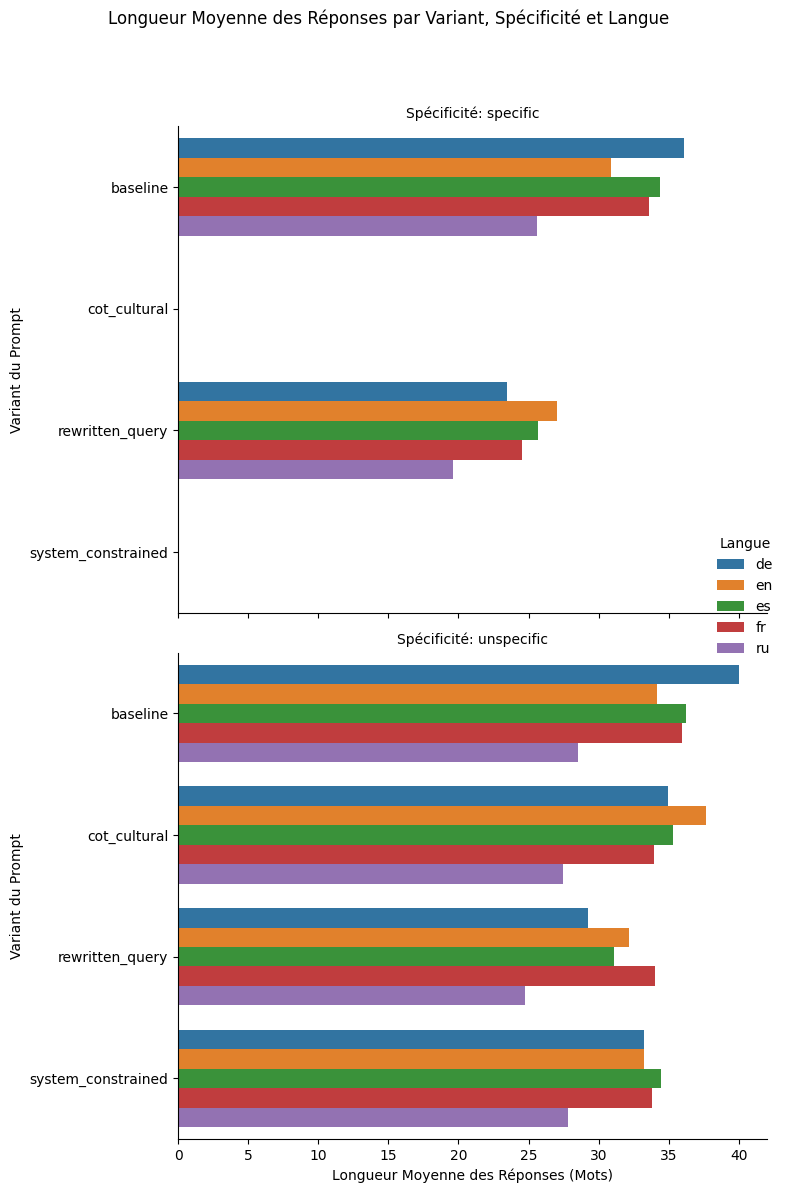



Détails de la longueur moyenne des réponses :


,Variant,Spécificité,Langue,Longueur moyenne des Réponses (Mots)
0,baseline,specific,de,36.086473
1,baseline,specific,en,30.865217
2,baseline,specific,es,34.415700
3,baseline,specific,fr,33.564327
4,baseline,specific,ru,25.634783
5,baseline,unspecific,de,40.039604
6,baseline,unspecific,en,34.168317
7,baseline,unspecific,es,36.237624
8,baseline,unspecific,fr,35.950495
9,baseline,unspecific,ru,28.534653


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure responses_df is available and contains 'answer' column
if 'responses_df' in locals() and not responses_df.empty and 'answer' in responses_df.columns:
    # 1. Calculate response word count
    responses_df['response_word_count'] = responses_df['answer'].apply(
        lambda x: len(str(x).split()) if pd.notna(x) else 0
    )

    # 2. Calculate average response length grouped by variant, specificity, and language
    avg_response_lengths = (
        responses_df.groupby(['prompt_type', 'specificity', 'language'])['response_word_count']
        .mean()
        .reset_index()
    )

    # 3. Rename columns for plotting clarity
    avg_response_lengths.columns = ['Variant', 'Spécificité', 'Langue', 'Longueur moyenne des Réponses (Mots)']

    # Sort the DataFrame for better visualization (e.g., sort by Variant then by Langue)
    avg_response_lengths_sorted = avg_response_lengths.sort_values(by=['Variant', 'Langue', 'Spécificité'])

    # 4. Create the catplot with horizontal bars
    # One plot per Specificity (row='Spécificité')
    # Y-axis will group by Variant
    # Hue will distinguish by Language, as requested
    g = sns.catplot(
        y='Variant', # Swapped x and y
        x='Longueur moyenne des Réponses (Mots)', # Swapped x and y
        hue='Langue',
        row='Spécificité',  # Separate plots for 'specific' and 'unspecific' contexts, arranged horizontally
        data=avg_response_lengths_sorted,
        kind='bar',
        palette='tab10', # Use a distinct palette for languages
        height=6,
        aspect=1.2,
        legend=True
    )

    # Set vertical spacing between subplots after FacetGrid creation
    g.fig.subplots_adjust(hspace=1.0) # Increased spacing between rows (specific and unspecific)

    g.set_axis_labels("Longueur Moyenne des Réponses (Mots)", "Variant du Prompt") # Updated labels
    g.set_titles("Spécificité: {row_name}") # Title for each row (Specificity)

    # Rotate y-axis labels for readability if needed (Variant labels are typically shorter, might not need rotation)
    for ax in g.axes.flat:
        if ax.get_yticklabels(): # Check for y-axis labels
            ax.set_yticklabels(ax.get_yticklabels())

    plt.suptitle('Longueur Moyenne des Réponses par Variant, Spécificité et Langue', y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()

    print("\n")
    print("Détails de la longueur moyenne des réponses :")
    display(avg_response_lengths)

else:
    print("DataFrame 'responses_df' non trouvé, vide ou colonne 'answer' manquante. Impossible de générer le graphique.")